In [2]:
from pathlib import Path
import pandas as pd

In [8]:
df = pd.read_csv(
    "../../temp_raw/SH2306_raw_files.txt", 
    sep=r'\s+',  # multiple spaces as delimiter
    header=None,  # no header
    names=['date', 'time', 'size', 'filename']  # assign column names
)

In [9]:
df

,date,time,size,filename
0,2024-12-23,15:20:21,105305912,Hake-D20230804-T152252.raw
1,2024-12-23,15:20:23,105302684,Hake-D20230804-T152713.raw
2,2024-12-23,15:20:23,105300892,Hake-D20230804-T153136.raw
3,2024-12-23,15:20:27,105300744,Hake-D20230804-T153600.raw
4,2024-12-23,15:20:30,105298712,Hake-D20230804-T154024.raw
...,...,...,...,...
3255,2024-12-30,10:58:31,105149748,Hake-D20230907-T012829.raw
3256,2024-12-30,10:58:32,105149976,Hake-D20230907-T013911.raw
3257,2024-12-30,10:58:34,105148328,Hake-D20230907-T014952.raw
3258,2024-12-30,10:58:56,105149812,Hake-D20230907-T020033.raw


In [11]:
from prefect.variables import Variable

In [17]:
Variable(name="counter_raw_copy", value=0, tags=[])

Variable(name='counter_raw_copy', value=0, tags=[])

In [21]:
Variable.set("counter_raw_copy", value=0, overwrite=True)

<coroutine object Variable.aset at 0x30901e980>

In [22]:
Variable.get("counter_raw_copy")

<coroutine object Variable.aget at 0x3092816c0>

In [27]:
df_Sv = pd.DataFrame(
    columns=[
        "raw_filename",
        "Sv_filename",
        "last_ping_time",
        "first_ping_time"
    ]
)

In [35]:
data_path = Path("/Users/wujung/code_git/echodataflow/temp_data")
Sv_csv_path = data_path / "SH2306_Sv_files.csv"
raw_path = data_path / "raw"

In [ ]:
df_Sv = pd.DataFrame(
    columns=["raw_filename", "Sv_filename", "last_ping_time", "first_ping_time"]
)
df_Sv.to_csv(Sv_csv_path)

In [33]:
Sv_csv_path = data_path / "SH2306_Sv_files.csv"
if not Sv_csv_path.exists():
    df_Sv = pd.DataFrame(
        columns=["raw_filename", "Sv_filename", "last_ping_time", "first_ping_time"]
    )
    df_Sv.to_csv(Sv_csv_path)
df_Sv = pd.read_csv(Sv_csv_path, index_col=0)

In [38]:
raw_files_in_folder = set([ff.name for ff in raw_path.glob("*.raw")])
raw_files_in_folder

{'Hake-D20230804-T152252.raw',
 'Hake-D20230804-T152713.raw',
 'Hake-D20230804-T153136.raw',
 'Hake-D20230804-T153600.raw',
 'Hake-D20230804-T154024.raw',
 'Hake-D20230804-T154445.raw',
 'Hake-D20230804-T154907.raw',
 'Hake-D20230804-T155328.raw',
 'Hake-D20230804-T155749.raw'}

In [40]:
df_Sv = pd.read_csv(Sv_csv_path, index_col=1)
df_Sv

,raw_filename,last_ping_time,first_ping_time
Sv_filename,,,
NaN,Hake-D20230804-T152252.raw,NaN,NaN
NaN,Hake-D20230804-T152713.raw,NaN,NaN


In [43]:
raw_files_in_df = set(df_Sv["raw_filename"].tolist())
raw_files_in_df

{'Hake-D20230804-T152252.raw', 'Hake-D20230804-T152713.raw'}

In [45]:
raw_files_in_folder.difference(raw_files_in_df)

{'Hake-D20230804-T153136.raw',
 'Hake-D20230804-T153600.raw',
 'Hake-D20230804-T154024.raw',
 'Hake-D20230804-T154445.raw',
 'Hake-D20230804-T154907.raw',
 'Hake-D20230804-T155328.raw',
 'Hake-D20230804-T155749.raw'}

In [48]:
df_Sv = pd.DataFrame(
    columns=["raw_filename", "Sv_filename", "last_ping_time", "first_ping_time"]
)
df_Sv.to_csv(Sv_csv_path)


In [51]:
df_Sv = pd.read_csv(Sv_csv_path, index_col=0)
df_Sv

,raw_filename,Sv_filename,last_ping_time,first_ping_time


In [53]:
raw_files_in_folder = set([ff.name for ff in raw_path.glob("*.raw")])
raw_files_in_df = set(df_Sv["raw_filename"].tolist())

In [54]:
# Find new files to process
new_files = raw_files_in_folder.difference(raw_files_in_df)
print(f"Found {len(new_files)} new files to process")

Found 9 new files to process


In [57]:
new_entries = []
for rf in new_files:
    print(rf)

Hake-D20230804-T153136.raw
Hake-D20230804-T154907.raw
Hake-D20230804-T152713.raw
Hake-D20230804-T154024.raw
Hake-D20230804-T154445.raw
Hake-D20230804-T152252.raw
Hake-D20230804-T155328.raw
Hake-D20230804-T153600.raw
Hake-D20230804-T155749.raw


In [61]:
list(new_files)

['Hake-D20230804-T153136.raw',
 'Hake-D20230804-T154907.raw',
 'Hake-D20230804-T152713.raw',
 'Hake-D20230804-T154024.raw',
 'Hake-D20230804-T154445.raw',
 'Hake-D20230804-T152252.raw',
 'Hake-D20230804-T155328.raw',
 'Hake-D20230804-T153600.raw',
 'Hake-D20230804-T155749.raw']

In [55]:
import echopype as ep

In [63]:
ed = ep.open_raw(
    raw_file=raw_path / list(new_files)[0],
    sonar_model="EK80",  # can be raw_kwargs
)


In [65]:
ds_Sv = ep.calibrate.compute_Sv(
    echodata=ed,
    waveform_mode="CW",  # can be Sv_kwargs
    encode_mode="power",
)

In [66]:
ds_Sv = ep.consolidate.add_depth(
    ds=ds_Sv,
    depth_offset=9.5,  # can be depth_kwargs
)

In [67]:
ed["Platform"] = ed["Platform"].drop_duplicates("time1")

In [68]:
ds_Sv = ep.consolidate.add_location(
    ds=ds_Sv,
    echodata=ed,
    nmea_sentence="GGA",  # can be location_kwargs
)

In [70]:
raw_path = data_path / "raw"
Sv_path = data_path / "Sv"

In [71]:
out_path = Sv_path / f"{raw_path.stem}_Sv.zarr"
out_path

PosixPath('/Users/wujung/code_git/echodataflow/temp_data/Sv/raw_Sv.zarr')

In [72]:
ds_Sv.to_zarr(
    store=out_path,
    mode="w",
    consolidated=True,
    # storage_options=config.output.storage_options_dict,
)
first_ping_time = ds_Sv["ping_time"][-1].values
last_ping_time = ds_Sv["ping_time"][0].values


In [73]:
first_ping_time, last_ping_time

(numpy.datetime64('2023-08-04T15:35:59.198755000'),
 numpy.datetime64('2023-08-04T15:31:36.971930000'))

In [74]:
new_files = raw_files_in_folder.difference(raw_files_in_df)

In [80]:
def raw2Sv(raw_path: str):
    """
    Convert raw sonar data to Sv and save to zarr format.
    """
    # Convert raw file, consolidate Sv and save to zarr
    ed = ep.open_raw(
        raw_file=raw_path,
        sonar_model="EK80",  # can be raw_kwargs
    )

    # Compute Sv and consolidate depth and location
    ds_Sv = ep.calibrate.compute_Sv(
        echodata=ed,
        waveform_mode="CW",  # can be Sv_kwargs
        encode_mode="power",
    )
    ds_Sv = ep.consolidate.add_depth(
        ds=ds_Sv,
        depth_offset=9.5,  # can be depth_kwargs
    )
    ed["Platform"] = ed["Platform"].drop_duplicates("time1")
    ds_Sv = ep.consolidate.add_location(
        ds=ds_Sv,
        echodata=ed,
        nmea_sentence="GGA",  # can be location_kwargs
    )
    
    # Save to zarr
    out_path = Sv_path / f"{raw_path.stem}_Sv.zarr"
    ds_Sv.to_zarr(
        store=out_path,
        mode="w",
        consolidated=True,
        # storage_options=config.output.storage_options_dict,
    )
    first_ping_time = ds_Sv["ping_time"][-1].values
    last_ping_time = ds_Sv["ping_time"][0].values

    return out_path.name, first_ping_time, last_ping_time

In [81]:
# Convert raw files to Sv
new_entries = []
for nf in new_files:
    Sv_filename, first_ping_time, last_ping_time = raw2Sv(raw_path / nf)
    new_entries.append([nf, Sv_filename, first_ping_time, last_ping_time])


In [82]:
if len(new_files) > 0:
    df_new = pd.DataFrame(
        new_entries,
        columns=["raw_filename", "Sv_filename", "last_ping_time", "first_ping_time"]
    )


In [83]:
df_new

,raw_filename,Sv_filename,last_ping_time,first_ping_time
0,Hake-D20230804-T153136.raw,Hake-D20230804-T153136_Sv.zarr,2023-08-04 15:35:59.198755,2023-08-04 15:31:36.971930
1,Hake-D20230804-T154907.raw,Hake-D20230804-T154907_Sv.zarr,2023-08-04 15:53:27.029600,2023-08-04 15:49:07.073324
2,Hake-D20230804-T152713.raw,Hake-D20230804-T152713_Sv.zarr,2023-08-04 15:31:35.772141,2023-08-04 15:27:13.129128
3,Hake-D20230804-T154024.raw,Hake-D20230804-T154024_Sv.zarr,2023-08-04 15:44:43.980598,2023-08-04 15:40:24.205114
4,Hake-D20230804-T154445.raw,Hake-D20230804-T154445_Sv.zarr,2023-08-04 15:49:05.872541,2023-08-04 15:44:45.177399
5,Hake-D20230804-T152252.raw,Hake-D20230804-T152252_Sv.zarr,2023-08-04 15:27:11.938807,2023-08-04 15:22:52.624729
6,Hake-D20230804-T155328.raw,Hake-D20230804-T155328_Sv.zarr,2023-08-04 15:57:48.550154,2023-08-04 15:53:28.239372
7,Hake-D20230804-T153600.raw,Hake-D20230804-T153600_Sv.zarr,2023-08-04 15:40:23.013302,2023-08-04 15:36:00.389574
8,Hake-D20230804-T155749.raw,Hake-D20230804-T155749_Sv.zarr,2023-08-04 16:02:14.032974,2023-08-04 15:57:49.758928


In [84]:
df_Sv = pd.concat([df_Sv, df_new], ignore_index=True)

/var/folders/1m/8nxc8r_900778tkhqfgh0nqh0000gn/T/ipykernel_47210/1860775217.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_Sv = pd.concat([df_Sv, df_new], ignore_index=True)


In [86]:
df_Sv

,raw_filename,Sv_filename,last_ping_time,first_ping_time
0,Hake-D20230804-T153136.raw,Hake-D20230804-T153136_Sv.zarr,2023-08-04 15:35:59.198755,2023-08-04 15:31:36.971930
1,Hake-D20230804-T154907.raw,Hake-D20230804-T154907_Sv.zarr,2023-08-04 15:53:27.029600,2023-08-04 15:49:07.073324
2,Hake-D20230804-T152713.raw,Hake-D20230804-T152713_Sv.zarr,2023-08-04 15:31:35.772141,2023-08-04 15:27:13.129128
3,Hake-D20230804-T154024.raw,Hake-D20230804-T154024_Sv.zarr,2023-08-04 15:44:43.980598,2023-08-04 15:40:24.205114
4,Hake-D20230804-T154445.raw,Hake-D20230804-T154445_Sv.zarr,2023-08-04 15:49:05.872541,2023-08-04 15:44:45.177399
5,Hake-D20230804-T152252.raw,Hake-D20230804-T152252_Sv.zarr,2023-08-04 15:27:11.938807,2023-08-04 15:22:52.624729
6,Hake-D20230804-T155328.raw,Hake-D20230804-T155328_Sv.zarr,2023-08-04 15:57:48.550154,2023-08-04 15:53:28.239372
7,Hake-D20230804-T153600.raw,Hake-D20230804-T153600_Sv.zarr,2023-08-04 15:40:23.013302,2023-08-04 15:36:00.389574
8,Hake-D20230804-T155749.raw,Hake-D20230804-T155749_Sv.zarr,2023-08-04 16:02:14.032974,2023-08-04 15:57:49.758928


In [87]:
a = raw2Sv(raw_path / nf)

In [89]:
["Hake-D20230804-T155749.raw"] + list(a)

['Hake-D20230804-T155749.raw',
 'Hake-D20230804-T155749_Sv.zarr',
 numpy.datetime64('2023-08-04T16:02:14.032974000'),
 numpy.datetime64('2023-08-04T15:57:49.758928000')]

In [92]:
import numpy as np

In [128]:
end_time = "2023-08-04T16:00:00"
slice_time_len = "10min"
num_slices = 3

In [129]:
end_time = pd.to_datetime(end_time)
slice_time_len = pd.to_timedelta(slice_time_len)
start_time = sorted([end_time - s * slice_time_len for s in np.arange(num_slices)+1])
end_time = [st + slice_time_len for st in start_time]

In [106]:
slice_time_len, start_time, end_time

(Timedelta('0 days 00:10:00'),
 [Timestamp('2023-08-04 15:30:00'),
  Timestamp('2023-08-04 15:40:00'),
  Timestamp('2023-08-04 15:50:00')],
 [Timestamp('2023-08-04 15:40:00'),
  Timestamp('2023-08-04 15:50:00'),
  Timestamp('2023-08-04 16:00:00')])

In [109]:
Sv_filenames = df_Sv[
    (pd.to_datetime(df_Sv["last_ping_time"]) >= start_time[0]) &
    (pd.to_datetime(df_Sv["first_ping_time"]) <= end_time[0])
]["Sv_filename"].tolist()
print(f"Found {len(Sv_filenames)} Sv files in the specified time range")


Found 3 Sv files in the specified time range


In [110]:
import xarray as xr

In [115]:
ds_Sv = xr.open_mfdataset(
    [Sv_path / svf for svf in Sv_filenames],
    parallel=True,
    chunks={"channel": 1, "ping_time": 1000, "range_sample": -1},
    engine="zarr",  # use zarr engine for reading
)


In [116]:
ds_Sv.chunks

Frozen({'channel': (1, 1, 1, 1, 1), 'ping_time': (214, 214, 214), 'range_sample': (36198,), 'filenames': (1,)})

In [117]:
ds_MVBS = ep.commongrid.compute_MVBS(
    ds_Sv,
    range_var="depth",
    range_bin='1m',
    ping_time_bin='5s',
    reindex=False,
    fill_value=np.nan,
)

In [118]:
ns = 0

In [119]:
MVBS_path = data_path / "MVBS"

In [123]:
out_path = MVBS_path / (
    f"MVBS_{start_time[ns].strftime('%Y%m%dT%H%M%S')}"
    f"_{end_time[ns].strftime('%Y%m%dT%H%M%S')}.zarr"
)
out_path

PosixPath('/Users/wujung/code_git/echodataflow/temp_data/MVBS/MVBS_20230804T153000_20230804T154000.zarr')

In [127]:
ds_MVBS = ep.commongrid.compute_MVBS(
    ds_Sv=ds_Sv.sel(ping_time=slice(start_time[ns], end_time[ns])),  # slice start/end
    range_var="depth",
    range_bin='1m',
    ping_time_bin='5s',
    reindex=False,
    fill_value=np.nan,
)
ds_MVBS.chunk({"channel": 1, "ping_time": -1, "depth": -1}).to_zarr(
    store=out_path,  # existing MVBS will be overwritten
    mode="w",
    consolidated=True,
    # storage_options=config.output.storage_options_dict,
)

In [2]:
import re

In [11]:
re.match(r"MVBS_(\w+).zarr", "MVBS_20230804T153000_20230804T154000.zarr").group(1)

'20230804T153000_20230804T154000'

In [12]:
import torch
from src.model.BinaryHakeModel import BinaryHakeModel

In [40]:
def get_hake_model(model_path: str) -> BinaryHakeModel:
    model = BinaryHakeModel("placeholder_experiment_name",
                            Path("placeholder_score_tensor_dir"),
                            "placeholder_tensor_log_dir", 0).eval()
    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu'))["state_dict"])
    return model

In [41]:
from pathlib import Path

In [42]:
model_epoch = 85
model_folder = "/Users/wujung/code_git/echodataflow/temp_model/model_160_epochs/model_weights"
model_path = f"{model_folder}/binary_hake_model_1.0m_bottom_offset_1.0m_depth_2017_2019_epoch_{model_epoch:03d}.ckpt"
model_path

'/Users/wujung/code_git/echodataflow/temp_model/model_160_epochs/model_weights/binary_hake_model_1.0m_bottom_offset_1.0m_depth_2017_2019_epoch_085.ckpt'

In [43]:
model = get_hake_model(model_path=model_path)

In [17]:
data_path = Path("/Users/wujung/code_git/echodataflow/temp_data")
raw_path = data_path / "raw"
Sv_path = data_path / "Sv"
MVBS_path = data_path / "MVBS"
prediction_path = data_path / "prediction"

In [18]:
mvbs_file = "MVBS_20230804T153000_20230804T154000.zarr"

In [19]:
import xarray as xr

In [20]:
ds_MVBS = xr.open_dataset(MVBS_path / mvbs_file, engine="zarr")

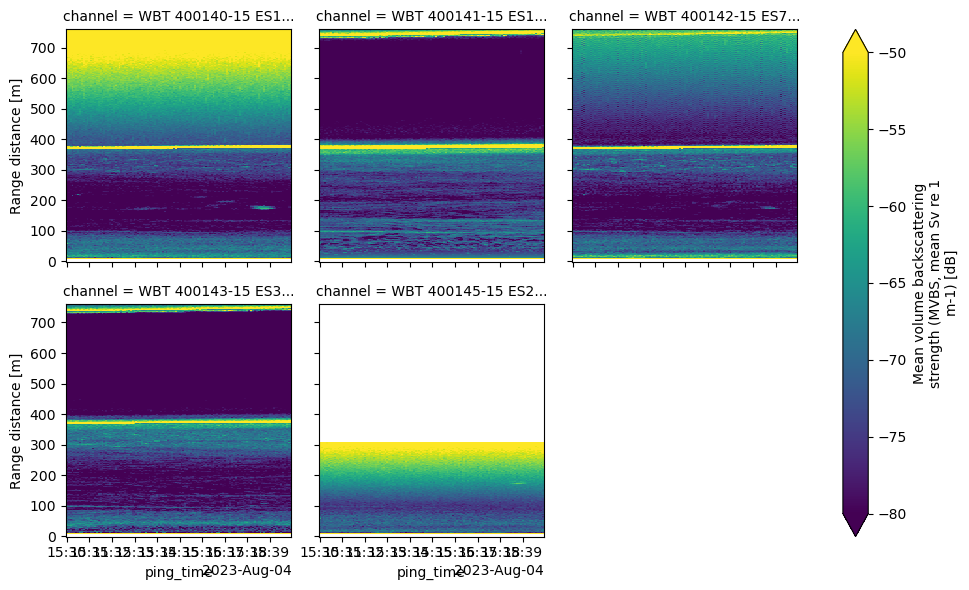

In [21]:
ds_MVBS["Sv"].plot(
    x="ping_time",
    y="depth",
    col="channel",
    col_wrap=3,
    cmap="viridis",
    vmin=-80,
    vmax=-50,
)

In [22]:
def get_MVBS_tensor(ds_in, freq_wanted=[120000, 38000, 18000]):
    # Find the right channel sequence
    ch_wanted = [int((np.abs(ds_in["frequency_nominal"]-freq)).argmin()) for freq in freq_wanted]

    mvbs_tensor = torch.tensor(
        (
            ds_in["Sv"]
            .transpose("channel", "depth", "ping_time")
            .isel(channel=ch_wanted).sel(depth=slice(None, 590)).values
        ),
        dtype=torch.float32
    )

    # Clip to Sv range
    mvbs_tensor_clip = torch.clip(
        mvbs_tensor.clone().detach().to(torch.float16),
        min=-70,
        max=-36,
    )

    # Replace NaN values with min Sv
    mvbs_tensor_clip[torch.isnan(mvbs_tensor_clip)] = -70

    # Normalize and conver to float
    mvbs_tensor_clip_normalized = (
        (mvbs_tensor_clip - (-70.0)) / (-36.0 - (-70.0)) * 255.0
    )
    
    return mvbs_tensor_clip_normalized.unsqueeze(0).float()

In [23]:
import numpy as np

In [24]:
ds_MVBS

<xarray.Dataset> Size: 4MB
Dimensions:            (channel: 5, ping_time: 120, depth: 760)
Coordinates:
  * channel            (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'W...
  * depth              (depth) float64 6kB 0.0 1.0 2.0 3.0 ... 757.0 758.0 759.0
  * ping_time          (ping_time) datetime64[ns] 960B 2023-08-04T15:30:00 .....
Data variables:
    Sv                 (channel, ping_time, depth) float64 4MB ...
    frequency_nominal  (ping_time, channel) float64 5kB ...
    latitude           (ping_time) float64 960B ...
    longitude          (ping_time) float64 960B ...
Attributes:
    processing_function:          commongrid.compute_MVBS
    processing_level:             Level 3A
    processing_level_url:         https://echopype.readthedocs.io/en/stable/p...
    processing_software_name:     echopype
    processing_software_version:  0.10.1
    processing_time:              2025-05-26T20:29:09Z

In [25]:
import pandas as pd

In [26]:
Sv_csv_path = data_path / "SH2306_Sv_files.csv"
df_Sv = pd.read_csv(Sv_csv_path, index_col=0)

In [48]:
end_time = "2023-08-04T16:00:00"
slice_time_len = "20min"
num_slices = 3

In [49]:
# Compute slice time range
end_time = pd.to_datetime(end_time)
slice_time_len = pd.to_timedelta(slice_time_len)
start_time = sorted([end_time - s * slice_time_len for s in np.arange(num_slices)+1])
end_time = [st + slice_time_len for st in start_time]    

In [50]:
start_time

[Timestamp('2023-08-04 15:00:00'),
 Timestamp('2023-08-04 15:20:00'),
 Timestamp('2023-08-04 15:40:00')]

In [51]:
end_time

[Timestamp('2023-08-04 15:20:00'),
 Timestamp('2023-08-04 15:40:00'),
 Timestamp('2023-08-04 16:00:00')]

In [29]:
df_Sv

,raw_filename,Sv_filename,last_ping_time,first_ping_time
0,Hake-D20230804-T160215.raw,Hake-D20230804-T160215_Sv.zarr,2023-08-04 16:06:36.909925,2023-08-04 16:02:15.256720
1,Hake-D20230804-T153600.raw,Hake-D20230804-T153600_Sv.zarr,2023-08-04 15:40:23.013302,2023-08-04 15:36:00.389574
2,Hake-D20230804-T154445.raw,Hake-D20230804-T154445_Sv.zarr,2023-08-04 15:49:05.872541,2023-08-04 15:44:45.177399
3,Hake-D20230804-T154024.raw,Hake-D20230804-T154024_Sv.zarr,2023-08-04 15:44:43.980598,2023-08-04 15:40:24.205114
4,Hake-D20230804-T152252.raw,Hake-D20230804-T152252_Sv.zarr,2023-08-04 15:27:11.938807,2023-08-04 15:22:52.624729
5,Hake-D20230804-T154907.raw,Hake-D20230804-T154907_Sv.zarr,2023-08-04 15:53:27.029600,2023-08-04 15:49:07.073324
6,Hake-D20230804-T155749.raw,Hake-D20230804-T155749_Sv.zarr,2023-08-04 16:02:14.032974,2023-08-04 15:57:49.758928
7,Hake-D20230804-T153136.raw,Hake-D20230804-T153136_Sv.zarr,2023-08-04 15:35:59.198755,2023-08-04 15:31:36.971930
8,Hake-D20230804-T155328.raw,Hake-D20230804-T155328_Sv.zarr,2023-08-04 15:57:48.550154,2023-08-04 15:53:28.239372
9,Hake-D20230804-T152713.raw,Hake-D20230804-T152713_Sv.zarr,2023-08-04 15:31:35.772141,2023-08-04 15:27:13.129128


In [30]:
ns = 0

In [31]:
# Get Sv files in the specified time range
Sv_filenames = df_Sv[
    (pd.to_datetime(df_Sv["last_ping_time"]) >= start_time[ns]) &
    (pd.to_datetime(df_Sv["first_ping_time"]) <= end_time[ns])
]["Sv_filename"].tolist()

MVBS_run_name = (
    f"MVBS_{start_time[ns].strftime("%Y%m%dT%H%M%S")}"
    f"_{end_time[ns].strftime("%Y%m%dT%H%M%S")}"
)

In [32]:
Sv_filenames

['Hake-D20230804-T153600_Sv.zarr',
 'Hake-D20230804-T153136_Sv.zarr',
 'Hake-D20230804-T152713_Sv.zarr']

In [39]:
xr.open_dataset(Sv_path / Sv_filenames[0], engine="zarr")

<xarray.Dataset> Size: 930MB
Dimensions:                        (channel: 5, ping_time: 214,
                                    range_sample: 36198, filenames: 1)
Coordinates:
  * channel                        (channel) <U25 500B 'WBT 400140-15 ES120-7...
  * filenames                      (filenames) int64 8B 0
  * ping_time                      (ping_time) datetime64[ns] 2kB 2023-08-04T...
  * range_sample                   (range_sample) int64 290kB 0 1 ... 36197
Data variables: (12/27)
    Sv                             (channel, ping_time, range_sample) float64 310MB ...
    angle_offset_alongship         (channel) float64 40B ...
    angle_offset_athwartship       (channel) float64 40B ...
    angle_sensitivity_alongship    (channel) float64 40B ...
    angle_sensitivity_athwartship  (channel) float64 40B ...
    beamwidth_alongship            (channel) float64 40B ...
    ...                             ...
    salinity                       float64 8B ...
    sound_absorption               (channel) float64 40B ...
    sound_speed                    float64 8B ...
    source_filenames               (filenames) <U76 304B ...
    temperature                    float64 8B ...
    water_level                    float64 8B ...
Attributes:
    processing_function:          calibrate.compute_Sv
    processing_level:             Level 2A
    processing_level_url:         https://echopype.readthedocs.io/en/stable/p...
    processing_software_name:     echopype
    processing_software_version:  0.10.1
    processing_time:              2025-05-23T22:15:43Z

In [47]:
ds_Sv = xr.open_mfdataset(
    [Sv_path / svf for svf in Sv_filenames],
    parallel=True,
    coords="minimal",
    data_vars="minimal",
    compat='override',
    chunks={"channel": 1, "ping_time": 1000, "range_sample": -1},
    engine="zarr",  # use zarr engine for reading
)
ds_Sv["frequency_nominal"].values

array([120000.,  18000.,  70000.,  38000., 200000.])

In [1]:
import echopype as ep
from pathlib import Path

In [2]:
data_path = Path("/Users/wujung/code_git/echodataflow/temp_data")

In [3]:
ed = ep.open_raw(
    raw_file=data_path / "raw/Hake-D20230804-T160215.raw",
    sonar_model="EK80",  # can be raw_kwargs
)

In [7]:
# Compute Sv and consolidate depth and location
ds_Sv = ep.calibrate.compute_Sv(
    echodata=ed,
    waveform_mode="CW",  # can be Sv_kwargs
    encode_mode="power",
)
ds_Sv["frequency_nominal"].dims

('channel',)

In [8]:
ds_Sv = ep.consolidate.add_depth(
    ds=ds_Sv,
    depth_offset=9.5,  # can be depth_kwargs
)
ds_Sv["frequency_nominal"].dims

('channel',)

In [9]:
ed["Platform"] = ed["Platform"].drop_duplicates("time1")
ds_Sv = ep.consolidate.add_location(
    ds=ds_Sv,
    echodata=ed,
    nmea_sentence="GGA",  # can be location_kwargs
)
ds_Sv["frequency_nominal"].dims

('channel',)

In [52]:
mvbs_file_list: list[str] = ["MVBS_20230804T154000_20230804T155000.zarr"]

In [54]:
from utils import get_MVBS_tensor, get_hake_model

In [55]:
model_epoch = 85
model_folder = "/Users/wujung/code_git/echodataflow/temp_model/model_160_epochs/model_weights"
model_path = f"{model_folder}/binary_hake_model_1.0m_bottom_offset_1.0m_depth_2017_2019_epoch_{model_epoch:03d}.ckpt"
model = get_hake_model(model_path)


In [57]:
ds_MVBS = xr.open_dataset(MVBS_path/mvbs_file, engine="zarr")
ds_MVBS

<xarray.Dataset> Size: 4MB
Dimensions:            (channel: 5, ping_time: 120, depth: 760)
Coordinates:
  * channel            (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'W...
  * depth              (depth) float64 6kB 0.0 1.0 2.0 3.0 ... 757.0 758.0 759.0
  * ping_time          (ping_time) datetime64[ns] 960B 2023-08-04T15:30:00 .....
Data variables:
    Sv                 (channel, ping_time, depth) float64 4MB ...
    frequency_nominal  (channel) float64 40B ...
    latitude           (ping_time) float64 960B ...
    longitude          (ping_time) float64 960B ...
Attributes:
    processing_function:          commongrid.compute_MVBS
    processing_level:             Level 3A
    processing_level_url:         https://echopype.readthedocs.io/en/stable/p...
    processing_software_name:     echopype
    processing_software_version:  0.10.1
    processing_time:              2025-05-29T23:15:26Z

In [63]:
mvbs_tensor = get_MVBS_tensor(ds_MVBS)

In [64]:
mvbs_tensor.shape

torch.Size([1, 3, 591, 120])

In [66]:
import torch

In [68]:
temperature = 0.5

In [69]:
score_tensor = model(mvbs_tensor).detach().squeeze(0)
score_tensor_softmax = torch.nn.functional.softmax(score_tensor / temperature, dim=0)

In [70]:
da_score = xr.DataArray(
    score_tensor,
    coords={
        "animal": ["background", "hake"],
        "depth": ds_MVBS["depth"].sel(depth=slice(None, 590)).values,
        "ping_time": ds_MVBS["ping_time"].values,
    }
)
da_score_softmax = xr.DataArray(
    score_tensor_softmax,
    coords={
        "animal": ["background", "hake"],
        "depth": ds_MVBS["depth"].sel(depth=slice(None, 590)).values,
        "ping_time": ds_MVBS["ping_time"].values,
    }
)

In [72]:
import re

In [74]:
mvbs_time = re.match(r"MVBS_(\w+).zarr", mvbs_file).group(1)
da_score.chunk({"animal": -1, "ping_time": -1, "depth": -1}).to_zarr(
    store=prediction_path / f"score_{mvbs_time}.zarr",
    mode="w",
    consolidated=True,
)
da_score_softmax.chunk({"animal": -1, "ping_time": -1, "depth": -1}).to_zarr(
    store=prediction_path / f"softmax_{mvbs_time}.zarr",
    mode="w",
    consolidated=True,
)

In [57]:
mvbs_tensor = get_MVBS_tensor(ds_MVBS)

ValueError: All-NaN slice encountered

In [3]:
import xarray as xr
from pathlib import Path

In [68]:
# Set up paths
data_path = Path("/Users/wujung/code_git/echodataflow/temp_data")
raw_path = data_path / "raw"
Sv_path = data_path / "Sv"
MVBS_path = data_path / "MVBS"
prediction_path = data_path / "prediction"

In [71]:
(MVBS_path / "MVBS_20230804T154000.zarr").exists()

False

In [72]:
ds_MVBS1 = xr.open_dataset(MVBS_path / "MVBS_20230804T153000.zarr", engine="zarr")
ds_MVBS2 = xr.open_dataset(MVBS_path / "MVBS_20230804T154000.zarr", engine="zarr")
ds_MVBS3 = xr.open_dataset(MVBS_path / "MVBS_20230804T155000.zarr", engine="zarr")

In [73]:
ds_MVBS1["ping_time"][[0, -1]].values

array(['2023-08-04T15:30:00.000000000', '2023-08-04T15:39:55.000000000'],
      dtype='datetime64[ns]')

In [74]:
ds_MVBS2["ping_time"][[0, -1]].values

array(['2023-08-04T15:40:00.000000000', '2023-08-04T15:49:55.000000000'],
      dtype='datetime64[ns]')

In [75]:
ds_MVBS3["ping_time"][[0, -1]].values

array(['2023-08-04T15:50:00.000000000', '2023-08-04T15:59:55.000000000'],
      dtype='datetime64[ns]')

In [76]:
import pandas as pd

In [12]:
MVBS_csv_path = data_path / "SH2306_MVBS_files.csv"
if not MVBS_csv_path.exists():
    df_MVBS = pd.DataFrame(
        columns=["MVBS_filename", "last_ping_time", "first_ping_time"]
    )
    df_MVBS.to_csv(MVBS_csv_path)

In [13]:
df_MVBS = pd.read_csv(MVBS_csv_path, index_col=0)

In [16]:
"MVBS_20230804T153000.zarr" in df_MVBS["MVBS_filename"]

False

In [18]:
len(df_MVBS["MVBS_filename"] == "MVBS_20230804T153000.zarr")

0

In [21]:
idx_to_add = len(df_MVBS) + 1
idx_to_add

1

In [47]:
df_MVBS.loc[idx_to_add] = [
    "MVBS_20230804T153000.zarr",
    ds_MVBS1["ping_time"][-1].values,
    ds_MVBS1["ping_time"][0].values
]

In [48]:
import numpy as np

In [49]:
idx = df_MVBS.index[df_MVBS["MVBS_filename"] == "MVBS_20230804T153000.zarr"]
idx

Index([1], dtype='int64')

In [50]:
df_MVBS

,MVBS_filename,last_ping_time,first_ping_time
1,MVBS_20230804T153000.zarr,2023-08-04T15:39:55.000000000,2023-08-04T15:30:00.000000000


In [51]:
df_MVBS.loc[idx] = [
    "MVBS_20230804T153000.zarr",
    ds_MVBS1["ping_time"][-2].values,
    ds_MVBS1["ping_time"][1].values
]

In [52]:
df_MVBS

,MVBS_filename,last_ping_time,first_ping_time
1,MVBS_20230804T153000.zarr,2023-08-04T15:39:50.000000000,2023-08-04T15:30:05.000000000


In [61]:
ds_predict1 = xr.open_dataset(prediction_path / "score_20230804T153500.zarr", engine="zarr")
ds_predict2 = xr.open_dataset(prediction_path / "score_20230804T154500.zarr", engine="zarr")
ds_predict3 = xr.open_dataset(prediction_path / "score_20230804T155500.zarr", engine="zarr")

In [62]:
ds_predict1["ping_time"][[0, -1]].values

array(['2023-08-04T15:35:00.000000000', '2023-08-04T15:44:55.000000000'],
      dtype='datetime64[ns]')

In [63]:
ds_predict2["ping_time"][[0, -1]].values

array(['2023-08-04T15:45:00.000000000', '2023-08-04T15:54:55.000000000'],
      dtype='datetime64[ns]')

In [64]:
ds_predict3["ping_time"][[0, -1]].values

array(['2023-08-04T15:55:00.000000000', '2023-08-04T15:59:55.000000000'],
      dtype='datetime64[ns]')

In [77]:
import datetime

In [79]:
datetime.datetime.fromisoformat("2023-08-04T16:05:00")

datetime.datetime(2023, 8, 4, 16, 5)

In [80]:
pd.to_datetime(datetime.datetime.fromisoformat("2023-08-04T16:05:00"))

Timestamp('2023-08-04 16:05:00')

In [ ]:
datetime.datetime.fromisoformat("2023-08-04T16:05:00").strftime("%Y-%m-%dT%H:%M:%S")

'2023-08-04T16:05:00'

In [87]:
def round_up_minutes(dt: datetime.datetime, interval: int) -> datetime.datetime:
    """Round down datetime to nearest interval minutes.
    
    Parameters
    ----------
    dt : datetime.datetime
        Datetime to round
    interval : int
        Interval in minutes to round to
        
    Returns
    -------
    datetime.datetime
        Rounded datetime
    """
    return dt.replace(
        minute=(dt.minute // interval) * interval + interval,
        second=0,
        microsecond=0
    )

In [88]:
round_up_minutes(
    datetime.datetime.fromisoformat("2023-08-04T16:17:00"),
    interval=5
)

datetime.datetime(2023, 8, 4, 16, 20)

In [93]:
from yaml import safe_load

In [101]:
with open("config.yaml", "r") as file:
    config = safe_load(file)


In [102]:
config

{'init': {'counter_raw_copy': 0, 'flow_start_time': '20230804T153000'},
 'copy_raw': {'interval': 2},
 'raw2Sv': {'interval': 5},
 'create_MVBS': {'interval': 10, 'slice_time_mins': 10, 'num_slices': 3},
 'predict_hake': {'interval': 10,
  'slice_time_mins': 10,
  'num_slices': 3,
  'temperature': 0.5}}

In [103]:
# Set interval dict
interval_dict = {}
for flow_name in config.keys():
    if flow_name != "init":
        interval_dict[flow_name] = config[flow_name].pop("interval", None)

In [105]:
interval_dict

{'copy_raw': 2, 'raw2Sv': 5, 'create_MVBS': 10, 'predict_hake': 10}

In [104]:
config

{'init': {'counter_raw_copy': 0, 'flow_start_time': '20230804T153000'},
 'copy_raw': {},
 'raw2Sv': {},
 'create_MVBS': {'slice_time_mins': 10, 'num_slices': 3},
 'predict_hake': {'slice_time_mins': 10, 'num_slices': 3, 'temperature': 0.5}}

In [98]:
{**config["predict_hake"]}

{'interval': 10, 'slice_time_mins': 10, 'num_slices': 3, 'temperature': 0.5}

In [99]:
config["predict_hake"].pop("interval", None)

10

In [100]:
config["predict_hake"]

{'slice_time_mins': 10, 'num_slices': 3, 'temperature': 0.5}

In [ ]:
# Pop reserved params from create_MVBS and predict_hake config dict
for reserved_param in ["interval"]:
    for flow_name in ["create_MVBS", "predict_hake"]:
        config[flow_name].pop(reserved_param, None)


In [95]:
for flow_name, flow_params in config.items():
    for p in flow_params:
        print(f"{flow_name}_{p}", config[flow_name][p])


create_MVBS_end_time None
create_MVBS_slice_time_len 10mins
predict_hake_end_time None
predict_hake_slice_time_len 10mins


In [106]:
init_dict = config.pop("init")

In [107]:
config

{'create_MVBS': {'end_time': None, 'slice_time_len': '10mins'},
 'predict_hake': {'end_time': None, 'slice_time_len': '10mins'}}

In [108]:
init_dict

{'counter_raw_copy': 0,
 'flow_start_time': datetime.datetime(2023, 8, 4, 16, 5)}

In [142]:
curr_time = datetime.datetime.fromisoformat("2023-08-04T15:50:00")
curr_time

datetime.datetime(2023, 8, 4, 15, 50)

In [143]:
curr_time_offset = datetime.datetime.now() - curr_time
curr_time, curr_time_offset

(datetime.datetime(2023, 8, 4, 15, 50),
 datetime.timedelta(days=666, seconds=1797, microseconds=473715))

In [144]:
datetime.timedelta(seconds=curr_time_offset.total_seconds())

datetime.timedelta(days=666, seconds=1797, microseconds=473715)

In [145]:
datetime.datetime.now() - datetime.timedelta(seconds=curr_time_offset.total_seconds())

datetime.datetime(2023, 8, 4, 15, 50, 22, 421169)

In [148]:
(
    datetime.datetime.now()
    - datetime.datetime.fromisoformat("2023-08-04T15:50:00")
).total_seconds()

57544516.794799

In [152]:
print(
    "flow started with parameters:\n"
    f"- end_time: {1}\n"
)

flow started with parameters:
- end_time: 1



In [153]:
create_MVBS__slice_time_len = "10mins"

In [154]:
def extract_mins(min_str: str) -> int:
    """Extract minutes from a string like '10mins'."""
    return int(min_str.replace("mins", ""))

In [155]:
extract_mins(create_MVBS__slice_time_len)

10

In [157]:
extract_mins(config["create_MVBS"]["slice_time_len"])

10

In [159]:
f"*/{extract_mins(config["create_MVBS"]["slice_time_len"])} * * * *"

'*/10 * * * *'

In [161]:
init_dict["flow_start_time"].strftime("%Y-%m-%dT%H:%M:%S")

'2023-08-04T16:05:00'

In [163]:
for flow_name, flow_params in config.items():
    print(flow_name.lower())

create_mvbs
predict_hake


In [170]:
f"{config["init"]["additional_offset_min"]}mins"

'7mins'

In [174]:
datetime.timedelta(minutes=config["init"]["additional_offset_min"])

datetime.timedelta(seconds=420)

In [176]:
round_up_minutes(
    (
        datetime.datetime.now()
        + datetime.timedelta(minutes=5)
        - datetime.timedelta(seconds=10)
    ),
interval=3
)

datetime.datetime(2025, 5, 31, 17, 33)

In [182]:
config["init"]["flow_start_time"]

'20230804T155000'

In [183]:
datetime.datetime.strptime(
    config["init"]["flow_start_time"], "%Y%m%dT%H%M%S"
)

datetime.datetime(2023, 8, 4, 15, 50)

In [187]:
round_up_minutes(
    (
        datetime.datetime.now()
        + datetime.timedelta(minutes=7)
        - datetime.timedelta(seconds=3)
    ),
    interval=3,
)

datetime.datetime(2025, 5, 31, 17, 48)

In [188]:
from prefect.variables import Variable

In [2]:
import datetime

In [1]:
curr_time_offset_seconds = 57548722.058271
slice_time_min = 10
additional_offset_min = 0

In [8]:
(
        datetime.datetime.now()
        + datetime.timedelta(minutes=additional_offset_min)
        - datetime.timedelta(seconds=curr_time_offset_seconds)
    )

datetime.datetime(2023, 8, 4, 16, 2, 20, 526416)

In [12]:
def round_up_minutes(dt: datetime.datetime, interval: int) -> datetime.datetime:
    # Round up minutes and handle day rollover
    minutes_since_midnight = dt.hour * 60 + dt.minute
    rounded_minutes = ((minutes_since_midnight + interval - 1) // interval) * interval
    
    days_to_add = rounded_minutes // (24 * 60)  # Number of days to add
    final_minutes = rounded_minutes % (24 * 60)  # Minutes in the final day
    
    return (dt
            .replace(hour=final_minutes // 60,
                    minute=final_minutes % 60,
                    second=0,
                    microsecond=0) 
            + datetime.timedelta(days=days_to_add))

In [19]:
round_up_minutes(
    (
        datetime.datetime.now()
        + datetime.timedelta(minutes=15)
        - datetime.timedelta(seconds=curr_time_offset_seconds)
    ),
    interval=slice_time_min,
)

datetime.datetime(2023, 8, 4, 16, 30)

In [22]:
import pandas as pd

In [24]:
pd.to_timedelta(f"{slice_time_min}min")

Timedelta('0 days 00:10:00')

In [20]:
slice_time_min

10

In [25]:
pd.to_datetime("2023-08-04T16:00:00")

Timestamp('2023-08-04 16:00:00')

In [30]:
from pathlib import Path
import xarray as xr

In [31]:
# Set up paths
data_path = Path("/Users/wujung/code_git/echodataflow/temp_data")
raw_path = data_path / "raw"
Sv_path = data_path / "Sv"
MVBS_path = data_path / "MVBS"
prediction_path = data_path / "prediction"

In [32]:
ds_MVBS1 = xr.open_dataset(MVBS_path / "MVBS_20230804T153000.zarr", engine="zarr")
ds_MVBS2 = xr.open_dataset(MVBS_path / "MVBS_20230804T154000.zarr", engine="zarr")
ds_MVBS3 = xr.open_dataset(MVBS_path / "MVBS_20230804T155000.zarr", engine="zarr")

In [33]:
ds_MVBS1["ping_time"][[0, -1]].values

array(['2023-08-04T15:30:00.000000000', '2023-08-04T15:39:55.000000000'],
      dtype='datetime64[ns]')

In [35]:
ds_MVBS2["ping_time"][[0, -1]].values

array(['2023-08-04T15:40:00.000000000', '2023-08-04T15:49:55.000000000'],
      dtype='datetime64[ns]')

In [36]:
first_ping_time, last_ping_time = ds_MVBS2["ping_time"][[0, -1]].values

In [37]:
first_ping_time, last_ping_time

(numpy.datetime64('2023-08-04T15:40:00.000000000'),
 numpy.datetime64('2023-08-04T15:49:55.000000000'))

In [ ]:
df = [pd.to_datetime(first_ping_time), pd.to_datetime(last_ping_time)]

(Timestamp('2023-08-04 15:40:00'), Timestamp('2023-08-04 15:49:55'))

In [41]:
df_MVBS = pd.DataFrame(
    columns=["MVBS_filename", "first_ping_time", "last_ping_time"]
)

In [43]:
len(df_MVBS)

0

In [44]:
df_MVBS.loc[0] = ["test", pd.to_datetime(first_ping_time), pd.to_datetime(last_ping_time)]

In [45]:
df_MVBS

,MVBS_filename,first_ping_time,last_ping_time
0,test,2023-08-04 15:40:00,2023-08-04 15:49:55


In [46]:
len(df_MVBS)

1

In [47]:
df_MVBS.loc[1] = ["test", first_ping_time, last_ping_time]

In [48]:
df_MVBS

,MVBS_filename,first_ping_time,last_ping_time
0,test,2023-08-04 15:40:00,2023-08-04 15:49:55
1,test,2023-08-04 15:40:00,2023-08-04 15:49:55


In [49]:
Path.cwd()

PosixPath('/Users/wujung/code_git/echodataflow/echodataflow/rewrite')

In [57]:
pd.to_datetime(first_ping_time, format="%Y-%m-%dT%H:%M:%S.%f", unit="ms")

Timestamp('2023-08-04 15:40:00')

In [56]:
pd.to_datetime(first_ping_time, format="%Y-%m-%dT%H:%M:%S.%f", unit="ns")

Timestamp('2023-08-04 15:40:00')

In [ ]:
pd.to_datetime(ds_MVBS1["ping_time"][0].values)

Timestamp('2023-08-04 15:30:00')

In [62]:
df_MVBS["first_ping_time"] = df_MVBS["first_ping_time"].dt.isoformat()
df_MVBS["last_ping_time"] = df_MVBS["last_ping_time"].dt.isoformat()

AttributeError: 'DatetimeProperties' object has no attribute 'isoformat'

In [65]:
df_MVBS["first_ping_time"].dt.isoformat()

AttributeError: 'DatetimeProperties' object has no attribute 'isoformat'

In [ ]:
MVBS_csv_path = data_path / "SH2306_MVBS_files.csv"
df_MVBS = pd.read_csv(MVBS_csv_path, index_col=0, date_format="ISO8601", parse_dates=["first_ping_time", "last_ping_time"])

In [74]:
df_MVBS

,MVBS_filename,first_ping_time,last_ping_time
0,MVBS_20230804T154000.zarr,2023-08-04T15:40:00.000000,2023-08-04T15:49:55.000000
1,MVBS_20230804T155000.zarr,2023-08-04 15:50:00,2023-08-04 15:59:55
2,MVBS_20230804T160000.zarr,2023-08-04 16:00:00,2023-08-04 16:09:55
3,MVBS_20230804T161000.zarr,2023-08-04 16:10:00,2023-08-04 16:19:55
4,MVBS_20230804T162000.zarr,2023-08-04 16:20:00,2023-08-04 16:28:30


In [89]:
Sv_csv_path = data_path / "SH2306_Sv_files.csv"
df_Sv = pd.read_csv(Sv_csv_path, index_col=0)

In [90]:
df_Sv

,raw_filename,Sv_filename,first_ping_time,last_ping_time
0,Hake-D20230804-T161945.raw,Hake-D20230804-T161945_Sv.zarr,2023-08-04 16:19:45.382215,2023-08-04 16:24:09.397343
1,Hake-D20230804-T152252.raw,Hake-D20230804-T152252_Sv.zarr,2023-08-04 15:22:52.624729,2023-08-04 15:27:11.938807
2,Hake-D20230804-T152713.raw,Hake-D20230804-T152713_Sv.zarr,2023-08-04 15:27:13.129128,2023-08-04 15:31:35.772141
3,Hake-D20230804-T153136.raw,Hake-D20230804-T153136_Sv.zarr,2023-08-04 15:31:36.971930,2023-08-04 15:35:59.198755
4,Hake-D20230804-T153600.raw,Hake-D20230804-T153600_Sv.zarr,2023-08-04 15:36:00.389574,2023-08-04 15:40:23.013302
5,Hake-D20230804-T154024.raw,Hake-D20230804-T154024_Sv.zarr,2023-08-04 15:40:24.205114,2023-08-04 15:44:43.980598
6,Hake-D20230804-T154445.raw,Hake-D20230804-T154445_Sv.zarr,2023-08-04 15:44:45.177399,2023-08-04 15:49:05.872541
7,Hake-D20230804-T154907.raw,Hake-D20230804-T154907_Sv.zarr,2023-08-04 15:49:07.073324,2023-08-04 15:53:27.029600
8,Hake-D20230804-T155328.raw,Hake-D20230804-T155328_Sv.zarr,2023-08-04 15:53:28.239372,2023-08-04 15:57:48.550154
9,Hake-D20230804-T155749.raw,Hake-D20230804-T155749_Sv.zarr,2023-08-04 15:57:49.758928,2023-08-04 16:02:14.032974


In [91]:
df_Sv.sort_values(by="first_ping_time", inplace=True, ignore_index=True)

In [92]:
df_Sv

,raw_filename,Sv_filename,first_ping_time,last_ping_time
0,Hake-D20230804-T152252.raw,Hake-D20230804-T152252_Sv.zarr,2023-08-04 15:22:52.624729,2023-08-04 15:27:11.938807
1,Hake-D20230804-T152713.raw,Hake-D20230804-T152713_Sv.zarr,2023-08-04 15:27:13.129128,2023-08-04 15:31:35.772141
2,Hake-D20230804-T153136.raw,Hake-D20230804-T153136_Sv.zarr,2023-08-04 15:31:36.971930,2023-08-04 15:35:59.198755
3,Hake-D20230804-T153600.raw,Hake-D20230804-T153600_Sv.zarr,2023-08-04 15:36:00.389574,2023-08-04 15:40:23.013302
4,Hake-D20230804-T154024.raw,Hake-D20230804-T154024_Sv.zarr,2023-08-04 15:40:24.205114,2023-08-04 15:44:43.980598
5,Hake-D20230804-T154445.raw,Hake-D20230804-T154445_Sv.zarr,2023-08-04 15:44:45.177399,2023-08-04 15:49:05.872541
6,Hake-D20230804-T154907.raw,Hake-D20230804-T154907_Sv.zarr,2023-08-04 15:49:07.073324,2023-08-04 15:53:27.029600
7,Hake-D20230804-T155328.raw,Hake-D20230804-T155328_Sv.zarr,2023-08-04 15:53:28.239372,2023-08-04 15:57:48.550154
8,Hake-D20230804-T155749.raw,Hake-D20230804-T155749_Sv.zarr,2023-08-04 15:57:49.758928,2023-08-04 16:02:14.032974
9,Hake-D20230804-T160215.raw,Hake-D20230804-T160215_Sv.zarr,2023-08-04 16:02:15.256720,2023-08-04 16:06:36.909925


In [3]:
from dask.distributed import Client
client = Client()

/Users/wujung/miniforge3/envs/echodataflow_20250529/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 52475 instead
  warnings.warn(


In [4]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:52475/status,
Dashboard: http://127.0.0.1:52475/status,Workers: 5
Total threads: 10,Total memory: 16.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:52476,Workers: 0
Dashboard: http://127.0.0.1:52475/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:52490,Total threads: 2
Dashboard: http://127.0.0.1:52495/status,Memory: 3.20 GiB
Nanny: tcp://127.0.0.1:52479,


In [6]:
del client

In [1]:
from pathlib import Path

In [2]:
list(Path("/Volumes/replay_test").glob("*"))

[PosixPath('/Volumes/replay_test/.DS_Store'),
 PosixPath('/Volumes/replay_test/._.DS_Store'),
 PosixPath('/Volumes/replay_test/gear_trial_replay-D20250308-T000018.raw'),
 PosixPath('/Volumes/replay_test/gear_trial_replay-D20250308-T000018.idx'),
 PosixPath('/Volumes/replay_test/gear_trial_replay-D20250308-T000107.raw'),
 PosixPath('/Volumes/replay_test/gear_trial_replay-D20250308-T000107.idx'),
 PosixPath('/Volumes/replay_test/gear_trial_replay-D20250308-T000154.raw'),
 PosixPath('/Volumes/replay_test/gear_trial_replay-D20250308-T000154.idx'),
 PosixPath('/Volumes/replay_test/gear_trial_replay-D20250308-T000247.raw'),
 PosixPath('/Volumes/replay_test/gear_trial_replay-D20250308-T000247.idx'),
 PosixPath('/Volumes/replay_test/gear_trial_replay-D20250308-T000335.raw'),
 PosixPath('/Volumes/replay_test/gear_trial_replay-D20250308-T000335.idx'),
 PosixPath('/Volumes/replay_test/gear_trial_replay-D20250308-T000417.raw'),
 PosixPath('/Volumes/replay_test/gear_trial_replay-D20250308-T000417.i

In [4]:
list(Path("/Users/wujung/code_git/echodataflow/temp_data_replay/raw").glob("*"))

[PosixPath('/Users/wujung/code_git/echodataflow/temp_data_replay/raw/.DS_Store'),
 PosixPath('/Users/wujung/code_git/echodataflow/temp_data_replay/raw/._.DS_Store'),
 PosixPath('/Users/wujung/code_git/echodataflow/temp_data_replay/raw/gear_trial_replay-D20250308-T000018.raw'),
 PosixPath('/Users/wujung/code_git/echodataflow/temp_data_replay/raw/gear_trial_replay-D20250308-T000018.idx'),
 PosixPath('/Users/wujung/code_git/echodataflow/temp_data_replay/raw/gear_trial_replay-D20250308-T000107.raw'),
 PosixPath('/Users/wujung/code_git/echodataflow/temp_data_replay/raw/gear_trial_replay-D20250308-T000107.idx'),
 PosixPath('/Users/wujung/code_git/echodataflow/temp_data_replay/raw/gear_trial_replay-D20250308-T000154.raw'),
 PosixPath('/Users/wujung/code_git/echodataflow/temp_data_replay/raw/gear_trial_replay-D20250308-T000154.idx'),
 PosixPath('/Users/wujung/code_git/echodataflow/temp_data_replay/raw/gear_trial_replay-D20250308-T000247.raw'),
 PosixPath('/Users/wujung/code_git/echodataflow/te

In [55]:
# Set up paths
data_path = Path("/Users/wujung/code_git/echodataflow/temp_data")
# raw_path = data_path / "raw"  # for SH2306
raw_path = Path("/Users/wujung/code_git/echodataflow/temp_data/raw")  # gear trial replay
Sv_path = data_path / "Sv"
MVBS_path = data_path / "MVBS"
prediction_path = data_path / "prediction"

In [8]:
if not Sv_path.exists():
    Sv_path.mkdir(parents=True, exist_ok=True)
if not MVBS_path.exists():
    MVBS_path.mkdir(parents=True, exist_ok=True)
if not prediction_path.exists():
    prediction_path.mkdir(parents=True, exist_ok=True)


In [7]:
Sv_path.exists()

False

In [3]:
import xarray as xr
from pathlib import Path

In [4]:
data_path = Path("/Users/wujung/code_git/echodataflow/temp_data")

In [8]:
da_softmax = xr.open_dataarray(
    data_path / "prediction/softmax_20230804T195000.zarr",
    engine="zarr"
)

In [9]:
da_softmax

<xarray.DataArray (class: 2, depth: 591, ping_time: 120)> Size: 567kB
[141840 values with dtype=float32]
Coordinates:
  * class      (class) <U10 80B 'background' 'hake'
  * depth      (depth) float64 5kB 0.0 1.0 2.0 3.0 ... 587.0 588.0 589.0 590.0
  * ping_time  (ping_time) datetime64[ns] 960B 2023-08-04T19:50:00 ... 2023-0...

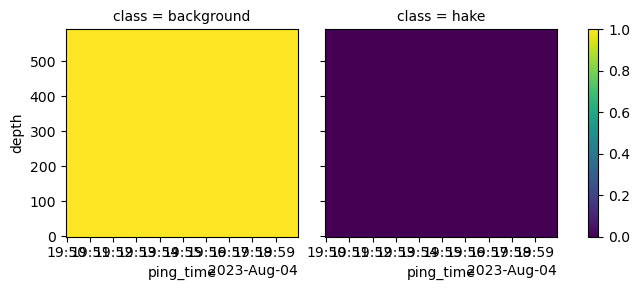

In [10]:
da_softmax.plot(x="ping_time", y="depth", col="class", col_wrap=2, cmap="viridis", vmin=0, vmax=1)

In [40]:
ds_MVBS = xr.open_dataset(data_path / "MVBS/MVBS_20230804T154000.zarr", engine="zarr")
ds_MVBS

<xarray.Dataset> Size: 4MB
Dimensions:            (channel: 5, ping_time: 120, depth: 760)
Coordinates:
  * channel            (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'W...
  * depth              (depth) float64 6kB 0.0 1.0 2.0 3.0 ... 757.0 758.0 759.0
  * ping_time          (ping_time) datetime64[ns] 960B 2023-08-04T15:40:00 .....
Data variables:
    Sv                 (channel, ping_time, depth) float64 4MB ...
    frequency_nominal  (channel) float64 40B ...
    latitude           (ping_time) float64 960B ...
    longitude          (ping_time) float64 960B ...
Attributes:
    processing_function:          commongrid.compute_MVBS
    processing_level:             Level 3A
    processing_level_url:         https://echopype.readthedocs.io/en/stable/p...
    processing_software_name:     echopype
    processing_software_version:  0.10.1
    processing_time:              2025-06-03T17:11:38Z

In [41]:
da_softmax = xr.open_dataarray(data_path / "prediction/softmax_20230804T154000.zarr", engine="zarr")
da_softmax

<xarray.DataArray (scatterer_class: 2, depth: 591, ping_time: 120)> Size: 567kB
[141840 values with dtype=float32]
Coordinates:
  * depth            (depth) float64 5kB 0.0 1.0 2.0 3.0 ... 588.0 589.0 590.0
  * ping_time        (ping_time) datetime64[ns] 960B 2023-08-04T15:40:00 ... ...
  * scatterer_class  (scatterer_class) <U10 80B 'background' 'hake'

In [42]:
softmax_threshold = 0.5
xr.where(da_softmax.sel(scatterer_class="hake") > softmax_threshold, True, False)

<xarray.DataArray (depth: 591, ping_time: 120)> Size: 71kB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
  * depth            (depth) float64 5kB 0.0 1.0 2.0 3.0 ... 588.0 589.0 590.0
  * ping_time        (ping_time) datetime64[ns] 960B 2023-08-04T15:40:00 ... ...
    scatterer_class  <U10 40B 'hake'

In [43]:
mask = xr.where(da_softmax.sel(scatterer_class="hake") > softmax_threshold, True, False)
mask

<xarray.DataArray (depth: 591, ping_time: 120)> Size: 71kB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
  * depth            (depth) float64 5kB 0.0 1.0 2.0 3.0 ... 588.0 589.0 590.0
  * ping_time        (ping_time) datetime64[ns] 960B 2023-08-04T15:40:00 ... ...
    scatterer_class  <U10 40B 'hake'

In [44]:
import echopype as ep

In [45]:
ds_MVBS = ds_MVBS.swap_dims({"channel": "frequency_nominal"}).sel(frequency_nominal=38000).sel(depth=slice(None, 590))

In [48]:
ds_MVBS["Sv"].shape, mask.shape

((120, 591), (591, 120))

In [51]:
ds_MVBS_masked = ep.mask.apply_mask(
    source_ds=ds_MVBS.transpose("depth", "ping_time"),
    mask=mask,
    var_name="Sv",
    fill_value=False,
)


In [135]:
ds_MVBS_combine = xr.open_mfdataset(
    [MVBS_path / mvbsf for mvbsf in ["MVBS_20230804T154000.zarr"]],
    parallel=True,
    coords="minimal",
    data_vars="minimal",
    compat='override',
    chunks={"channel": -1, "ping_time": -1, "depth": -1},  # load everything into 1 chunk
    engine="zarr",  # use zarr engine for reading
).sel(
    # slice start/end, end exclusive
    # ping_time=slice(start_time, end_time-pd.to_timedelta("10milliseconds")),
    depth=slice(None, 590)  # slice depth to match hake model input
).transpose("channel", "ping_time", "depth")  # transpose to match dimension order of mask
                                    # TODO: remove once update echopype to 0.10.2

In [92]:
da_softmax_combine = xr.open_mfdataset(
    [prediction_path / softmaxf for softmaxf in ["softmax_20230804T154000.zarr"]],
    parallel=True,
    coords="minimal",
    data_vars="minimal",
    compat='override',
    engine="zarr",  # use zarr engine for reading
).sel(
    # slice start/end, end exclusive
    # ping_time=slice(start_time, end_time-pd.to_timedelta("10milliseconds"))
).to_dataarray().isel(variable=0).sel(scatterer_class="hake").transpose("ping_time", "depth")  # TODO: remove once update echopype to 0.10.2

In [141]:
da_softmax_combine = xr.open_mfdataset(
    [prediction_path / softmaxf for softmaxf in ["softmax_20230804T154000.zarr"]],
    parallel=True,
    coords="minimal",
    data_vars="minimal",
    compat='override',
    chunks={"scatterer_class": -1, "ping_time": -1, "depth": -1},  # load everything into 1 chunk
    engine="zarr",  # use zarr engine for reading
).sel(
    # slice start/end, end exclusive
    # ping_time=slice(start_time, end_time-pd.to_timedelta("10milliseconds"))
).to_dataarray()
da_softmax_combine = (
    da_softmax_combine.isel(variable=0).sel(scatterer_class="hake")
    .transpose("ping_time", "depth")  # TODO: remove once update echopype to 0.10.2
).drop_vars(["scatterer_class", "variable"])

In [142]:
import numpy as np

In [143]:
ds_MVBS_combine_masked = ep.mask.apply_mask(
    source_ds=ds_MVBS_combine,
    mask=da_softmax_combine > 0.02,
    var_name="Sv",
    fill_value=np.nan,
)#.drop_vars(["scatterer_class", "variable"])
ds_MVBS_combine_masked


<xarray.Dataset> Size: 3MB
Dimensions:            (channel: 5, ping_time: 120, depth: 591)
Coordinates:
  * channel            (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'W...
  * depth              (depth) float64 5kB 0.0 1.0 2.0 3.0 ... 588.0 589.0 590.0
  * ping_time          (ping_time) datetime64[ns] 960B 2023-08-04T15:40:00 .....
Data variables:
    Sv                 (channel, ping_time, depth) float64 3MB dask.array<chunksize=(5, 120, 591), meta=np.ndarray>
    frequency_nominal  (channel) float64 40B dask.array<chunksize=(5,), meta=np.ndarray>
    latitude           (ping_time) float64 960B dask.array<chunksize=(120,), meta=np.ndarray>
    longitude          (ping_time) float64 960B dask.array<chunksize=(120,), meta=np.ndarray>
Attributes:
    processing_function:          commongrid.compute_MVBS
    processing_level:             Level 3A
    processing_level_url:         https://echopype.readthedocs.io/en/stable/p...
    processing_software_name:     echopype
    processing_software_version:  0.10.1
    processing_time:              2025-06-03T17:11:38Z
    mask_software_name:           echopype
    mask_software_version:        0.10.1
    mask_time:                    2025-06-03T17:58:54Z
    mask_function:                mask.apply_mask

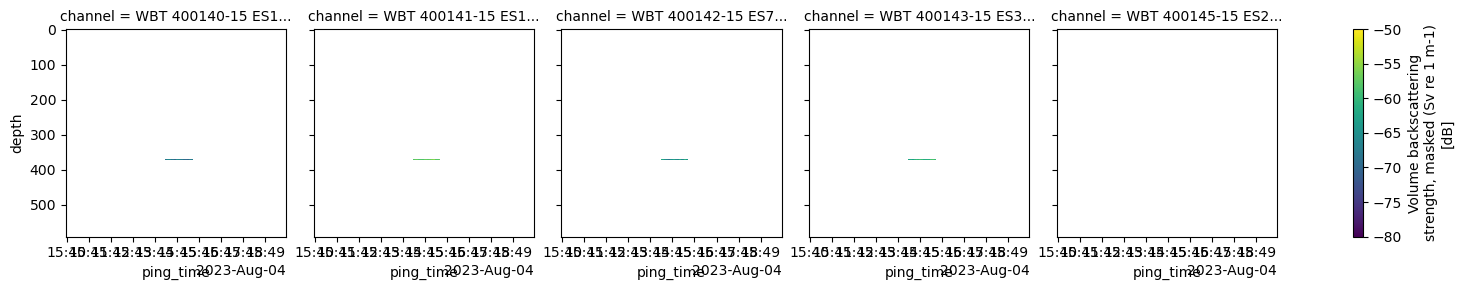

In [127]:
ds_MVBS_combine_masked["Sv"].plot(
    x="ping_time", y="depth", col="channel", yincrease=False,
    cmap="viridis", vmin=-80, vmax=-50,
)

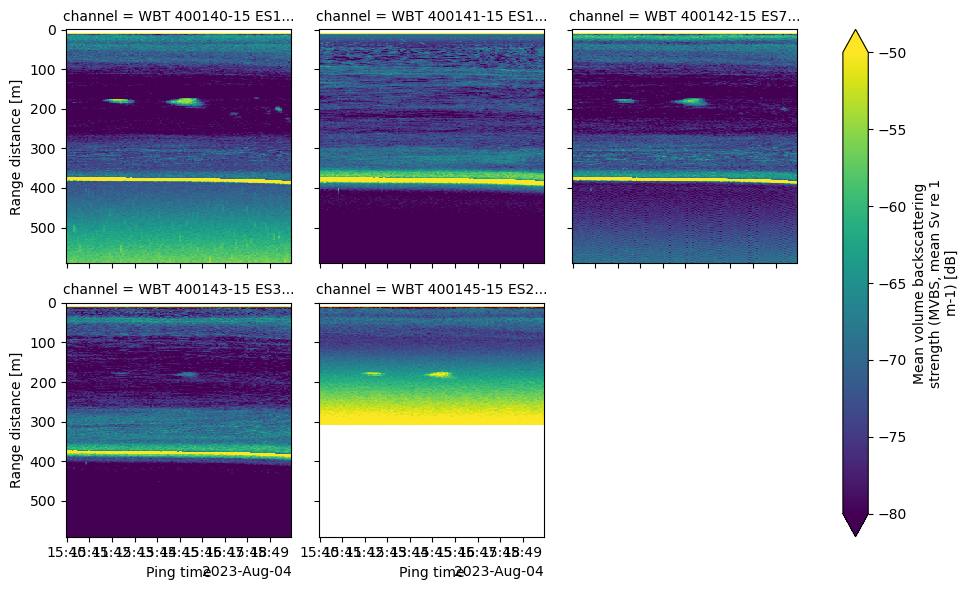

In [128]:
ds_MVBS_combine["Sv"].plot(
    x="ping_time", y="depth", col="channel", yincrease=False,
    col_wrap=3, cmap="viridis", vmin=-80, vmax=-50
)

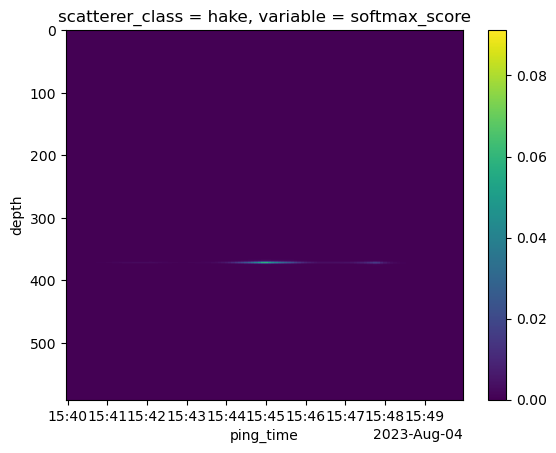

In [129]:
da_softmax_combine.plot(x="ping_time", y="depth", yincrease=False)

In [130]:
(da_softmax_combine > softmax_threshold).values

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

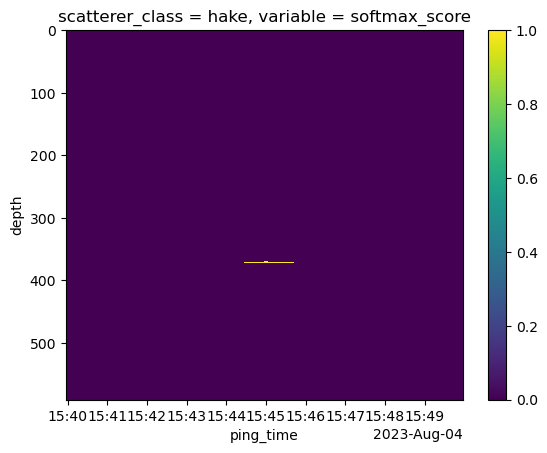

In [132]:
(da_softmax_combine > 0.02).plot(x="ping_time", y="depth", yincrease=False)

In [144]:
# Compute NASC from MVBS and hake prediction
ds_NASC = ep.commongrid.compute_NASC(
    ds_Sv=ds_MVBS_combine_masked,
    range_bin="10m",
    dist_bin="0.5nmi"
)

In [145]:
ds_NASC

<xarray.Dataset> Size: 3kB
Dimensions:            (channel: 5, distance: 1, depth: 59)
Coordinates:
  * distance           (distance) float64 8B 0.0
  * channel            (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'W...
  * depth              (depth) float64 472B 0.0 10.0 20.0 ... 560.0 570.0 580.0
Data variables:
    NASC               (channel, distance, depth) float64 2kB dask.array<chunksize=(5, 1, 59), meta=np.ndarray>
    latitude           (distance) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    longitude          (distance) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    ping_time          (distance) datetime64[ns] 8B 2023-08-04T15:44:57.500000
    frequency_nominal  (channel) float64 40B dask.array<chunksize=(5,), meta=np.ndarray>
Attributes:
    Conventions:           CF-1.7,ACDD-1.3
    time_coverage_start:   2023-08-04T15:40:00.000000000Z
    time_coverage_end:     2023-08-04T15:49:55.000000000Z
    geospatial_lat_min:    43.23421
    geospatial_lat_max:    43.24016
    geospatial_lon_min:    -124.77647
    geospatial_lon_max:    -124.77633
    processing_level:      Level 4
    processing_level_url:  https://echopype.readthedocs.io/en/stable/processi...

In [148]:
xr.open_dataset(
    data_path / "NASC/NASC_20230804T154000.zarr",
    engine="zarr"
)["NASC"].values

array([[[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]],

       [[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]],

       [[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan,

In [149]:
import xarray as xr

In [150]:
data_path = Path("/Users/wujung/code_git/echodataflow/temp_data")

In [152]:
ds_MVBS = xr.open_dataset(
    data_path / "MVBS/MVBS_20230804T165000.zarr",
    engine="zarr"
)
ds_MVBS

<xarray.Dataset> Size: 4MB
Dimensions:            (channel: 5, ping_time: 120, depth: 760)
Coordinates:
  * channel            (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'W...
  * depth              (depth) float64 6kB 0.0 1.0 2.0 3.0 ... 757.0 758.0 759.0
  * ping_time          (ping_time) datetime64[ns] 960B 2023-08-04T16:50:00 .....
Data variables:
    Sv                 (channel, ping_time, depth) float64 4MB ...
    frequency_nominal  (channel) float64 40B ...
    latitude           (ping_time) float64 960B ...
    longitude          (ping_time) float64 960B ...
Attributes:
    processing_function:          commongrid.compute_MVBS
    processing_level:             Level 3A
    processing_level_url:         https://echopype.readthedocs.io/en/stable/p...
    processing_software_name:     echopype
    processing_software_version:  0.10.1
    processing_time:              2025-06-04T20:20:14Z

In [154]:
ds_score = xr.open_dataset(
    data_path / "prediction/score_20230804T165000.zarr",
    engine="zarr"
)
ds_score

<xarray.Dataset> Size: 573kB
Dimensions:          (depth: 591, ping_time: 120, scatterer_class: 2)
Coordinates:
  * depth            (depth) float64 5kB 0.0 1.0 2.0 3.0 ... 588.0 589.0 590.0
  * ping_time        (ping_time) datetime64[ns] 960B 2023-08-04T16:50:00 ... ...
  * scatterer_class  (scatterer_class) <U10 80B 'background' 'hake'
Data variables:
    score            (scatterer_class, depth, ping_time) float32 567kB ...

In [155]:
ds_softmax = xr.open_dataset(
    data_path / "prediction/softmax_20230804T165000.zarr",
    engine="zarr"
)
ds_softmax

<xarray.Dataset> Size: 573kB
Dimensions:          (depth: 591, ping_time: 120, scatterer_class: 2)
Coordinates:
  * depth            (depth) float64 5kB 0.0 1.0 2.0 3.0 ... 588.0 589.0 590.0
  * ping_time        (ping_time) datetime64[ns] 960B 2023-08-04T16:50:00 ... ...
  * scatterer_class  (scatterer_class) <U10 80B 'background' 'hake'
Data variables:
    softmax_score    (scatterer_class, depth, ping_time) float32 567kB ...

In [157]:
import pandas as pd

In [158]:
# Sample sigma_bs_df:
sigma_bs_df = pd.DataFrame({
    # Grouping columns
    'stratum': [1, 1, 2, 2],           # Spatial stratum number
    'haul_num': [3, 3, 3, 3],          # Haul number 
    'species_id': [161, 161, 161, 161], # 161 = Pacific hake
    
    # Computed values
    'sigma_bs': [-34.2, -33.8, -34.5, -33.9],      # Mean backscattering cross-section (dB)
    'sigma_bs_count': [82, 89, 65, 72],            # Number of fish in each group
    'sigma_bs_sum': [-2804.4, -3008.2, -2242.5, -2440.8]  # Sum of sigma_bs values
})

In [159]:
sigma_bs_df

,stratum,haul_num,species_id,sigma_bs,sigma_bs_count,sigma_bs_sum
0,1,3,161,-34.2,82,-2804.4
1,1,3,161,-33.8,89,-3008.2
2,2,3,161,-34.5,65,-2242.5
3,2,3,161,-33.9,72,-2440.8


In [160]:
specimen_df = pd.DataFrame({
    'operation_number': [3, 3, 3],
    'species': ['Pacific hake'] * 3,
    'length': [24.1, 24.2, 24.3],  # Precise measurements
    'sex': ['Female', 'Female', 'Male'],
    'weight': [0.090, 0.080, 0.102]
})
specimen_df

,operation_number,species,length,sex,weight
0,3,Pacific hake,24.1,Female,0.090
1,3,Pacific hake,24.2,Female,0.080
2,3,Pacific hake,24.3,Male,0.102


In [161]:
length_df = pd.DataFrame({
    'operation_number': [3, 3],
    'species': ['Pacific hake'] * 2,
    'rounded_length': [24, 24],  # Binned lengths
    'sex': ['Female', 'Male'],
    'frequency': [82, 82]  # Count in each bin
})
length_df

,operation_number,species,rounded_length,sex,frequency
0,3,Pacific hake,24,Female,82
1,3,Pacific hake,24,Male,82


In [162]:
# Example of combined length_datasets
length_datasets = pd.DataFrame({
    'operation_number': [3, 3, 3, 3],
    'species': ['Pacific hake'] * 4,
    'length': [24.0, 24.0, 24.0, 24.0],  # Binned to nearest cm
    'sex': ['Female', 'Female', 'Male', 'Male'],
    'length_count': [2, 80, 1, 81],      # Individual specimens + remaining count
    'has_weight': [True, False, True, False]  # Flags rows from specimen_data
})
length_datasets

,operation_number,species,length,sex,length_count,has_weight
0,3,Pacific hake,24.0,Female,2,True
1,3,Pacific hake,24.0,Female,80,False
2,3,Pacific hake,24.0,Male,1,True
3,3,Pacific hake,24.0,Male,81,False


In [167]:
exclude_subdirs = ["test1", "test2", "test3"]
exclude_filename = "upload_exclude_folders.txt"
with open(exclude_filename, "w") as f:
    for subdir in exclude_subdirs:
        f.write(f"{subdir}/**\n")

In [165]:
from pathlib import Path

In [166]:
Path.cwd()

PosixPath('/Users/wujung/code_git/echodataflow/echodataflow/rewrite')

In [169]:
from yaml import safe_load
with open("config.yaml", "r") as file:
    config = safe_load(file)

In [170]:
config

{'init': {'counter_raw_copy': 0, 'flow_start_time': '20230804T155000'},
 'copy_raw': {'interval': 2},
 'raw2Sv': {'interval': 5, 'parallel': False, 'encode_mode': 'power'},
 'create_MVBS': {'interval': 10, 'slice_mins': 10, 'num_slices': 3},
 'predict_hake': {'interval': 10,
  'slice_mins': 10,
  'num_slices': 3,
  'temperature': 0.5},
 'compute_NASC': {'interval': 10,
  'slice_mins': 10,
  'num_slices': 3,
  'softmax_threshold': 0.5},
 'flow_file_upload': {'interval': 10,
  'src_dir': '/Users/wujung/code_git/echodataflow/temp_upload_test',
  'dest_dir': 'osn_sdsc_hake:/agr230002-bucket01/prefect_test',
  'exclude_subdirs': ['test1', 'test2']}}

In [171]:
import re
from pathlib import Path
import pandas as pd

In [173]:
bio_path = Path("/Users/wujung/code_git/echodataflow/temp_bio")
date_prefix = "202407"
species_code = 22500

In [174]:
bio_filenames = {
    "length": list(bio_path.glob(f"{date_prefix}_{species_code}_*_lf.csv")),
    "specimen": list(bio_path.glob(f"{date_prefix}_{species_code}_*_spec.csv")),
    "catch": list(bio_path.glob(f"{date_prefix}_*_catch_perc.csv")),
    "info": list(bio_path.glob(f"{date_prefix}_*_operation_info.csv")),
}

In [225]:
a = re.match(rf"{date_prefix}_({species_code}_)?(?P<haul_num>\d{{3}})_\w+\.csv", "202407_22500_041_lf.csv")
a["haul_num"]

'041'

In [224]:
a = re.match(rf"{date_prefix}_({species_code}_)?(?P<haul_num>\d{{3}})_\w+\.csv", "202407_008_catch_perc.csv")
a["haul_num"]

'008'

In [264]:
HAUL_NUM_PATTERN = rf"{date_prefix}_({species_code}_)?(?P<haul_num>\d{{3}})_\w+\.csv"
haul_num_all = {k: set() for k in bio_filenames.keys()}

In [265]:
for file_type in bio_filenames.keys():
    for fname in bio_filenames[file_type]:
        haul_num_all[file_type].add(int(re.match(HAUL_NUM_PATTERN, fname.name)["haul_num"]))

In [266]:
all_hauls = set.union(*haul_num_all.values())
len(all_hauls)

43

In [267]:
haul_num_to_remove = set()
for file_type in bio_filenames.keys():
    haul_num_diff = all_hauls.difference(haul_num_all[file_type])
    print(haul_num_diff)
    if haul_num_diff:
        haul_num_to_remove.update(haul_num_diff)
        print(haul_num_to_remove)

{39, 18, 56, 57, 30, 63}
{18, 39, 56, 57, 30, 63}
{39, 56, 57, 30, 63}
{39, 18, 56, 57, 30, 63}
{45}
{39, 45, 18, 56, 57, 30, 63}
{45}
{39, 45, 18, 56, 57, 30, 63}


In [268]:
all_hauls.difference_update(haul_num_to_remove)
len(all_hauls)

36

In [282]:
data_path = Path("/Users/wujung/code_git/echodataflow/temp_bio")
csv_path = data_path / "bio_csv"

In [283]:
haul_num = 11

In [284]:
f"{date_prefix}_{species_code}_{haul_num:03d}_lf.csv"

'202407_22500_011_lf.csv'

In [285]:
df_length = pd.read_csv(
    csv_path / f"{date_prefix}_{species_code}_{haul_num:03d}_lf.csv", index_col=0
)
df_length

,partition,species,sex,rounded_length,frequency
operation_number,,,,,
11,Codend,Pacific hake - Merluccius productus,Female,22.0,1
11,Codend,Pacific hake - Merluccius productus,Female,23.0,1
11,Codend,Pacific hake - Merluccius productus,Female,24.0,14
11,Codend,Pacific hake - Merluccius productus,Female,25.0,45
11,Codend,Pacific hake - Merluccius productus,Female,26.0,50
11,Codend,Pacific hake - Merluccius productus,Female,27.0,34
11,Codend,Pacific hake - Merluccius productus,Female,28.0,26
11,Codend,Pacific hake - Merluccius productus,Female,29.0,10
11,Codend,Pacific hake - Merluccius productus,Female,30.0,5


In [286]:
df_specimen = pd.read_csv(
    csv_path / f"{date_prefix}_{species_code}_{haul_num:03d}_spec.csv", index_col=0
)
df_specimen

,partition,species,length_type,length,sex,organism_weight,barcode
operation_number,,,,,,,
11,Codend,Pacific hake - Merluccius productus,fork_length,24.0,Male,0.090,100634244
11,Codend,Pacific hake - Merluccius productus,fork_length,24.0,Male,0.100,100634239
11,Codend,Pacific hake - Merluccius productus,fork_length,24.1,Female,0.095,100634227
11,Codend,Pacific hake - Merluccius productus,fork_length,24.1,Male,0.090,100634231
11,Codend,Pacific hake - Merluccius productus,fork_length,24.2,Male,0.085,100634139
11,Codend,Pacific hake - Merluccius productus,fork_length,24.4,Female,0.090,100634210
11,Codend,Pacific hake - Merluccius productus,fork_length,24.5,Female,0.085,100634137
11,Codend,Pacific hake - Merluccius productus,fork_length,24.5,Male,0.100,100634248
11,Codend,Pacific hake - Merluccius productus,fork_length,24.6,Female,0.100,100634132


In [293]:
df_specimen["rounded_length"] = df_specimen["length"].round(0)
df_specimen

,partition,species,length_type,length,sex,organism_weight,barcode,length_rounded,rounded_length
operation_number,,,,,,,,,
11,Codend,Pacific hake - Merluccius productus,fork_length,24.0,Male,0.090,100634244,24.0,24.0
11,Codend,Pacific hake - Merluccius productus,fork_length,24.0,Male,0.100,100634239,24.0,24.0
11,Codend,Pacific hake - Merluccius productus,fork_length,24.1,Female,0.095,100634227,24.0,24.0
11,Codend,Pacific hake - Merluccius productus,fork_length,24.1,Male,0.090,100634231,24.0,24.0
11,Codend,Pacific hake - Merluccius productus,fork_length,24.2,Male,0.085,100634139,24.0,24.0
11,Codend,Pacific hake - Merluccius productus,fork_length,24.4,Female,0.090,100634210,24.0,24.0
11,Codend,Pacific hake - Merluccius productus,fork_length,24.5,Female,0.085,100634137,24.0,24.0
11,Codend,Pacific hake - Merluccius productus,fork_length,24.5,Male,0.100,100634248,24.0,24.0
11,Codend,Pacific hake - Merluccius productus,fork_length,24.6,Female,0.100,100634132,25.0,25.0


In [315]:
specimen_counts = (
    df_specimen
    .groupby(["sex", "rounded_length"])
    .size()
    .reset_index(name="frequency")
)
specimen_counts

,sex,rounded_length,frequency
0,Female,24.0,3
1,Female,25.0,5
2,Female,26.0,8
3,Female,27.0,4
4,Female,28.0,1
5,Female,30.0,1
6,Female,32.0,1
7,Female,33.0,1
8,Female,38.0,1
9,Male,24.0,5


In [316]:
length_counts = (
    df_length
    .groupby(["sex", "rounded_length"])
    .agg({"frequency": "sum"})
    .reset_index()
)
length_counts

,sex,rounded_length,frequency
0,Female,22.0,1
1,Female,23.0,1
2,Female,24.0,14
3,Female,25.0,45
4,Female,26.0,50
5,Female,27.0,34
6,Female,28.0,26
7,Female,29.0,10
8,Female,30.0,5
9,Female,31.0,4


In [323]:
df_combined = pd.merge(
    specimen_counts.reset_index(),
    length_counts.reset_index(),
    on=["sex", "rounded_length"],
    how="outer"
).fillna(0)
df_combined["frequency"] = (df_combined["frequency_x"] + df_combined["frequency_y"]).astype(int)
df_combined

,index_x,sex,rounded_length,frequency_x,index_y,frequency_y,frequency
0,0.0,Female,22.0,0.0,0,1,1
1,0.0,Female,23.0,0.0,1,1,1
2,0.0,Female,24.0,3.0,2,14,17
3,1.0,Female,25.0,5.0,3,45,50
4,2.0,Female,26.0,8.0,4,50,58
5,3.0,Female,27.0,4.0,5,34,38
6,4.0,Female,28.0,1.0,6,26,27
7,0.0,Female,29.0,0.0,7,10,10
8,5.0,Female,30.0,1.0,8,5,6
9,0.0,Female,31.0,0.0,9,4,4


In [325]:
df_combined = df_combined[["sex", "rounded_length", "frequency"]]
df_combined

,sex,rounded_length,frequency
0,Female,22.0,1
1,Female,23.0,1
2,Female,24.0,17
3,Female,25.0,50
4,Female,26.0,58
5,Female,27.0,38
6,Female,28.0,27
7,Female,29.0,10
8,Female,30.0,6
9,Female,31.0,4


In [334]:
def get_count_from_length_specimen(
    df_length: pd.DataFrame,
    df_specimen: pd.DataFrame,
) -> pd.DataFrame:
    """
    Get length count from length and specimen dataframes.
    """
    # Round fish length to nearest integer
    df_specimen["rounded_length"] = df_specimen["length"].round(0)

    # Get length count from both dataframes
    specimen_counts = df_specimen.groupby(["sex", "rounded_length"]).size().reset_index(name="frequency")
    length_counts = df_length.groupby(["sex", "rounded_length"]).agg({"frequency": "sum"}).reset_index()
    
    df_combined = pd.merge(
        specimen_counts.reset_index(),
        length_counts.reset_index(),
        on=["sex", "rounded_length"],
        how="outer"
    ).fillna(0)
    df_combined["frequency"] = (df_combined["frequency_x"] + df_combined["frequency_y"]).astype(int)

    return df_combined[["sex", "rounded_length", "frequency"]]

In [335]:
df_combined_func = get_count_from_length_specimen(df_length, df_specimen)

In [336]:
df_combined_func.equals(df_combined)

True

In [363]:
df_info = pd.read_csv(
    csv_path / f"{date_prefix}_{haul_num:03d}_operation_info.csv", index_col=0
).reset_index()
df_info

,operation_number,td_timestamp,td_latitude,td_longitude
0,11,20240712000333,37.160085,-122.833601


In [364]:
df_info.columns.tolist()

Index(['operation_number', 'td_timestamp', 'td_latitude', 'td_longitude'], dtype='object')

In [366]:
df_info.iloc[0].values

array([ 1.10000000e+01,  2.02407120e+13,  3.71600855e+01, -1.22833601e+02])

In [362]:
df_info.iloc[1]

IndexError: single positional indexer is out-of-bounds

In [369]:
pd.merge(
    df_combined,
    df_info, 
    how='cross'  # This will create all possible combinations
)

,sex,rounded_length,frequency,operation_number,td_timestamp,td_latitude,td_longitude
0,Female,22.0,1,11,20240712000333,37.160085,-122.833601
1,Female,23.0,1,11,20240712000333,37.160085,-122.833601
2,Female,24.0,17,11,20240712000333,37.160085,-122.833601
3,Female,25.0,50,11,20240712000333,37.160085,-122.833601
4,Female,26.0,58,11,20240712000333,37.160085,-122.833601
5,Female,27.0,38,11,20240712000333,37.160085,-122.833601
6,Female,28.0,27,11,20240712000333,37.160085,-122.833601
7,Female,29.0,10,11,20240712000333,37.160085,-122.833601
8,Female,30.0,6,11,20240712000333,37.160085,-122.833601
9,Female,31.0,4,11,20240712000333,37.160085,-122.833601


In [372]:
df_specimen

,partition,species,length_type,length,sex,organism_weight,barcode,length_rounded,rounded_length
operation_number,,,,,,,,,
11,Codend,Pacific hake - Merluccius productus,fork_length,24.0,Male,0.090,100634244,24.0,24.0
11,Codend,Pacific hake - Merluccius productus,fork_length,24.0,Male,0.100,100634239,24.0,24.0
11,Codend,Pacific hake - Merluccius productus,fork_length,24.1,Female,0.095,100634227,24.0,24.0
11,Codend,Pacific hake - Merluccius productus,fork_length,24.1,Male,0.090,100634231,24.0,24.0
11,Codend,Pacific hake - Merluccius productus,fork_length,24.2,Male,0.085,100634139,24.0,24.0
11,Codend,Pacific hake - Merluccius productus,fork_length,24.4,Female,0.090,100634210,24.0,24.0
11,Codend,Pacific hake - Merluccius productus,fork_length,24.5,Female,0.085,100634137,24.0,24.0
11,Codend,Pacific hake - Merluccius productus,fork_length,24.5,Male,0.100,100634248,24.0,24.0
11,Codend,Pacific hake - Merluccius productus,fork_length,24.6,Female,0.100,100634132,25.0,25.0


In [ ]:
# Fit length-weight linear regression by male, female, and all fish
length_weight_regression_df = (
    df_specimen.groupby(["species_id", "sex"])
    .apply(
        lambda df: pd.Series(
            np.polyfit(np.log10(df["length"]), np.log10(df["weight"]), 1),
            index=["rate", "initial"],
        ),
        # include_groups=False,
    )
    .reset_index()
)


In [390]:
df_length_weight_regression = df_specimen.groupby("sex").apply(
    lambda df: pd.Series(
        np.polyfit(np.log10(df["length"]), np.log10(df["organism_weight"]), 1),
        index=["p1", "p2"],
    )
).reset_index()
df_length_weight_regression

/var/folders/1m/8nxc8r_900778tkhqfgh0nqh0000gn/T/ipykernel_2553/2157825564.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_length_weight_regression = df_specimen.groupby("sex").apply(


,sex,p1,p2
0,Female,2.989974,-5.178500
1,Male,2.820425,-4.927556


In [394]:
np.polyfit(np.log10(df_specimen["length"]), np.log10(df_specimen["organism_weight"]), 1).tolist()

[2.910460410576882, -5.0601123522122515]

In [399]:
len(df_length_weight_regression)

2

In [403]:
pd.DataFrame(
    ["all"] + np.polyfit(np.log10(df_specimen["length"]), np.log10(df_specimen["organism_weight"]), 1).tolist(),
    index=["sex", "p1", "p2"]
).T

,sex,p1,p2
0,all,2.91046,-5.060112


In [ ]:
df_length_weight_regression = pd.concat(
    [
        df_length_weight_regression,
        pd.DataFrame(
            ["all"] + np.polyfit(np.log10(df_specimen["length"]), np.log10(df_specimen["organism_weight"]), 1).tolist(),
            index=["sex", "p1", "p2"]
        ).T
    ],
)

In [511]:
df_length_weight_regression

,index,sex,stratum,p1,p2
0,0,female,2,2.989974,-5.178500
1,1,male,2,2.820425,-4.927556
2,0,all,2,2.910460,-5.060112


In [509]:
import matplotlib.pyplot as plt

In [407]:
df_length_weight_regression["sex"] = df_length_weight_regression["sex"].str.lower()
df_length_weight_regression

,sex,p1,p2
0,female,2.989974,-5.1785
1,male,2.820425,-4.927556
0,all,2.91046,-5.060112


In [410]:
df_specimen_with_lat_lon = pd.merge(
    df_specimen,
    df_info[["td_latitude", "td_longitude"]],
    how="cross"  # create all possible combinations, but we only have 1 row here
)
df_specimen_with_lat_lon

,partition,species,length_type,length,sex,organism_weight,barcode,length_rounded,rounded_length,td_latitude,td_longitude
0,Codend,Pacific hake - Merluccius productus,fork_length,24.0,Male,0.090,100634244,24.0,24.0,37.160085,-122.833601
1,Codend,Pacific hake - Merluccius productus,fork_length,24.0,Male,0.100,100634239,24.0,24.0,37.160085,-122.833601
2,Codend,Pacific hake - Merluccius productus,fork_length,24.1,Female,0.095,100634227,24.0,24.0,37.160085,-122.833601
3,Codend,Pacific hake - Merluccius productus,fork_length,24.1,Male,0.090,100634231,24.0,24.0,37.160085,-122.833601
4,Codend,Pacific hake - Merluccius productus,fork_length,24.2,Male,0.085,100634139,24.0,24.0,37.160085,-122.833601
5,Codend,Pacific hake - Merluccius productus,fork_length,24.4,Female,0.090,100634210,24.0,24.0,37.160085,-122.833601
6,Codend,Pacific hake - Merluccius productus,fork_length,24.5,Female,0.085,100634137,24.0,24.0,37.160085,-122.833601
7,Codend,Pacific hake - Merluccius productus,fork_length,24.5,Male,0.100,100634248,24.0,24.0,37.160085,-122.833601
8,Codend,Pacific hake - Merluccius productus,fork_length,24.6,Female,0.100,100634132,25.0,25.0,37.160085,-122.833601
9,Codend,Pacific hake - Merluccius productus,fork_length,24.7,Male,0.100,100634136,25.0,25.0,37.160085,-122.833601


In [449]:
def get_length_weight_regression(df_specimen: pd.DataFrame) -> pd.DataFrame:
    """
    Get length-weight regression coefficients for male, female, and all fish combined.
    """
    # Male, female separately
    df_regres = df_specimen.groupby(["sex", "stratum"]).apply(
        lambda df: pd.Series(
            np.polyfit(np.log10(df["length"]), np.log10(df["organism_weight"]), 1),
            index=["p1", "p2"],
        ),
        include_groups = False
    ).reset_index()

    # All fish combined
    df_all = df_specimen.groupby("stratum").apply(
        lambda df: pd.Series(
            np.polyfit(np.log10(df["length"]),
                    np.log10(df["organism_weight"]), 1),
            index=["p1", "p2"],
        ),
        include_groups = False
    ).reset_index()
    df_all["sex"] = "all"

    # Combine all and make everything lowercase
    df_regres = pd.concat([df_regres, df_all]).reset_index()
    df_regres["sex"] = df_regres["sex"].str.lower()
    
    return df_regres

In [450]:
df_specimen_with_lat_lon["stratum"] = 1

In [451]:
df_specimen_with_lat_lon

,partition,species,length_type,length,sex,organism_weight,barcode,length_rounded,rounded_length,td_latitude,td_longitude,stratum
0,Codend,Pacific hake - Merluccius productus,fork_length,24.0,Male,0.090,100634244,24.0,24.0,37.160085,-122.833601,1
1,Codend,Pacific hake - Merluccius productus,fork_length,24.0,Male,0.100,100634239,24.0,24.0,37.160085,-122.833601,1
2,Codend,Pacific hake - Merluccius productus,fork_length,24.1,Female,0.095,100634227,24.0,24.0,37.160085,-122.833601,1
3,Codend,Pacific hake - Merluccius productus,fork_length,24.1,Male,0.090,100634231,24.0,24.0,37.160085,-122.833601,1
4,Codend,Pacific hake - Merluccius productus,fork_length,24.2,Male,0.085,100634139,24.0,24.0,37.160085,-122.833601,1
5,Codend,Pacific hake - Merluccius productus,fork_length,24.4,Female,0.090,100634210,24.0,24.0,37.160085,-122.833601,1
6,Codend,Pacific hake - Merluccius productus,fork_length,24.5,Female,0.085,100634137,24.0,24.0,37.160085,-122.833601,1
7,Codend,Pacific hake - Merluccius productus,fork_length,24.5,Male,0.100,100634248,24.0,24.0,37.160085,-122.833601,1
8,Codend,Pacific hake - Merluccius productus,fork_length,24.6,Female,0.100,100634132,25.0,25.0,37.160085,-122.833601,1
9,Codend,Pacific hake - Merluccius productus,fork_length,24.7,Male,0.100,100634136,25.0,25.0,37.160085,-122.833601,1


In [452]:
get_length_weight_regression(df_specimen_with_lat_lon)

,index,sex,stratum,p1,p2
0,0,female,1,2.989974,-5.178500
1,1,male,1,2.820425,-4.927556
2,0,all,1,2.910460,-5.060112


In [453]:
def create_inpfc_strata(spatial_config: dict):

    # Extract the INPFC definitions
    inpfc_definitions = spatial_config["inpfc"]

    # Create latitude bins
    latitude_bins = np.concatenate([[-90.0], inpfc_definitions["latitude_max"], [90.0]])
    # ---- Append 1 more stratum layer
    bin_names = np.concatenate(
        [inpfc_definitions["stratum_names"], [np.max(inpfc_definitions["stratum_names"]) + 1]]
    )

    # Create spatial key
    inpfc_strata_df = pd.DataFrame(
        {
            "latitude_limit": np.concatenate([inpfc_definitions["latitude_max"], [90.0]]),
            "latitude_interval": pd.cut(
                np.concatenate([inpfc_definitions["latitude_max"], [90.0]]), latitude_bins
            ),
            "stratum": bin_names,
        }
    )

    # Add boundaries
    # ---- Lower
    inpfc_strata_df["lower"] = inpfc_strata_df["latitude_interval"].apply(lambda x: x.left)
    # ---- Upper
    inpfc_strata_df["upper"] = inpfc_strata_df["latitude_interval"].apply(lambda x: x.right)

    # Return the dataframe
    return inpfc_strata_df

In [455]:
df_stratum = pd.read_csv(
    data_path / "inpfc_def.csv", index_col=0
)
df_stratum

,latitude_northern_limit,stratum_name
stratum_num,,
1,36.0000,Conception
2,40.5000,Monterey
3,43.0000,Eureka
4,45.7667,South Columbia
5,48.5000,North Columbia - US/CAN border
6,55.0000,Canada


In [457]:
df_specimen_with_lat_lon.pop("stratum")

0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
20    1
21    1
22    1
23    1
24    1
25    1
26    1
27    1
28    1
29    1
30    1
31    1
32    1
33    1
34    1
35    1
36    1
37    1
38    1
39    1
40    1
41    1
42    1
43    1
44    1
45    1
46    1
47    1
48    1
49    1
50    1
51    1
Name: stratum, dtype: int64

In [461]:
# Create latitude bins from the stratum definitions
lat_bins = [-90.0] + df_stratum["latitude_northern_limit"].tolist() + [90.0]
lat_labels = df_stratum.index.tolist() + [max(df_stratum.index) + 1]

# Add stratum column based on td_latitude
df_specimen_with_lat_lon["stratum"] = pd.cut(
    df_specimen_with_lat_lon["td_latitude"],
    bins=lat_bins,
    labels=lat_labels,
    include_lowest=True
).astype(int)

In [462]:
df_specimen_with_lat_lon

,partition,species,length_type,length,sex,organism_weight,barcode,length_rounded,rounded_length,td_latitude,td_longitude,stratum
0,Codend,Pacific hake - Merluccius productus,fork_length,24.0,Male,0.090,100634244,24.0,24.0,37.160085,-122.833601,2
1,Codend,Pacific hake - Merluccius productus,fork_length,24.0,Male,0.100,100634239,24.0,24.0,37.160085,-122.833601,2
2,Codend,Pacific hake - Merluccius productus,fork_length,24.1,Female,0.095,100634227,24.0,24.0,37.160085,-122.833601,2
3,Codend,Pacific hake - Merluccius productus,fork_length,24.1,Male,0.090,100634231,24.0,24.0,37.160085,-122.833601,2
4,Codend,Pacific hake - Merluccius productus,fork_length,24.2,Male,0.085,100634139,24.0,24.0,37.160085,-122.833601,2
5,Codend,Pacific hake - Merluccius productus,fork_length,24.4,Female,0.090,100634210,24.0,24.0,37.160085,-122.833601,2
6,Codend,Pacific hake - Merluccius productus,fork_length,24.5,Female,0.085,100634137,24.0,24.0,37.160085,-122.833601,2
7,Codend,Pacific hake - Merluccius productus,fork_length,24.5,Male,0.100,100634248,24.0,24.0,37.160085,-122.833601,2
8,Codend,Pacific hake - Merluccius productus,fork_length,24.6,Female,0.100,100634132,25.0,25.0,37.160085,-122.833601,2
9,Codend,Pacific hake - Merluccius productus,fork_length,24.7,Male,0.100,100634136,25.0,25.0,37.160085,-122.833601,2


In [ ]:
df_specimen_with_lat_lon

In [473]:
haul_num = 11
df_length = pd.read_csv(
    csv_path / f"{date_prefix}_{species_code}_{haul_num:03d}_lf.csv", index_col=0
)
df_specimen = pd.read_csv(
    csv_path / f"{date_prefix}_{species_code}_{haul_num:03d}_spec.csv", index_col=0
)
df_length_count = get_count_from_length_specimen(df_length, df_specimen)

In [474]:
# Add haul number and lat/lon for downstream stratification
df_info = pd.read_csv(
    csv_path / f"{date_prefix}_{haul_num:03d}_operation_info.csv", index_col=0
).reset_index()  # reset index to get operation_number into a column
df_specimen = pd.merge(
    df_specimen,
    df_info,
    how="cross"  # create all possible combinations, but we only have 1 row here
)
df_length_count = pd.merge(
    df_length_count,
    df_info, 
    how="cross"  # create all possible combinations, but we only have 1 row here
)

In [476]:
def add_stratum(df, df_stratum):
    # Create latitude bins from the stratum definitions
    lat_bins = [-90.0] + df_stratum["latitude_northern_limit"].tolist() + [90.0]
    lat_labels = df_stratum.index.tolist() + [max(df_stratum.index) + 1]

    # Add stratum column based on td_latitude
    df["stratum"] = pd.cut(
        df["td_latitude"],
        bins=lat_bins,
        labels=lat_labels,
        include_lowest=True
    ).astype(int)

    return df

In [477]:
# Add stratrum info to df_specimen and df_length_count based on latitude
df_stratum = pd.read_csv(data_path / "inpfc_def.csv", index_col=0)
df_specimen = add_stratum(df_specimen, df_stratum)
df_length_count = add_stratum(df_length_count, df_stratum)

In [478]:
df_length_weight_regression = get_length_weight_regression(df_specimen)

In [481]:
from core import TS_L_PARAMS

In [488]:
10 ** ((
    TS_L_PARAMS["slope"] * np.log10(df_length_count["rounded_length"])
    + TS_L_PARAMS["intercept"]
) / 10)

0     0.000077
1     0.000084
2     0.000091
3     0.000099
4     0.000107
5     0.000116
6     0.000124
7     0.000133
8     0.000143
9     0.000152
10    0.000162
11    0.000173
12    0.000183
13    0.000194
14    0.000205
15    0.000229
16    0.000307
17    0.000321
18    0.000365
19    0.000412
20    0.000077
21    0.000084
22    0.000091
23    0.000099
24    0.000107
25    0.000116
26    0.000124
27    0.000133
28    0.000143
29    0.000152
30    0.000162
31    0.000173
32    0.000183
33    0.000194
34    0.000205
35    0.000217
36    0.000280
Name: rounded_length, dtype: float64

In [490]:
df_length_count["sigma_bs"] = 10 ** ((
    TS_L_PARAMS["slope"] * np.log10(df_length_count["rounded_length"])
    + TS_L_PARAMS["intercept"]
) / 10)

In [491]:
df_length_count

,sex,rounded_length,frequency,operation_number,td_timestamp,td_latitude,td_longitude,stratum,sigma_bs
0,Female,22.0,1,11,20240712000333,37.160085,-122.833601,2,0.000077
1,Female,23.0,1,11,20240712000333,37.160085,-122.833601,2,0.000084
2,Female,24.0,17,11,20240712000333,37.160085,-122.833601,2,0.000091
3,Female,25.0,50,11,20240712000333,37.160085,-122.833601,2,0.000099
4,Female,26.0,58,11,20240712000333,37.160085,-122.833601,2,0.000107
5,Female,27.0,38,11,20240712000333,37.160085,-122.833601,2,0.000116
6,Female,28.0,27,11,20240712000333,37.160085,-122.833601,2,0.000124
7,Female,29.0,10,11,20240712000333,37.160085,-122.833601,2,0.000133
8,Female,30.0,6,11,20240712000333,37.160085,-122.833601,2,0.000143
9,Female,31.0,4,11,20240712000333,37.160085,-122.833601,2,0.000152


In [505]:
df_sigma_bs_mean = df_length_count.groupby("stratum").apply(
    lambda df: pd.Series(
        (df["sigma_bs"] * df["frequency"]).sum() / df["frequency"].sum(),
        index=["sigma_bs_mean"],
    ),
    include_groups=False
).reset_index()
df_sigma_bs_mean

,stratum,sigma_bs_mean
0,2,0.00012


In [494]:
import matplotlib.pyplot as plt

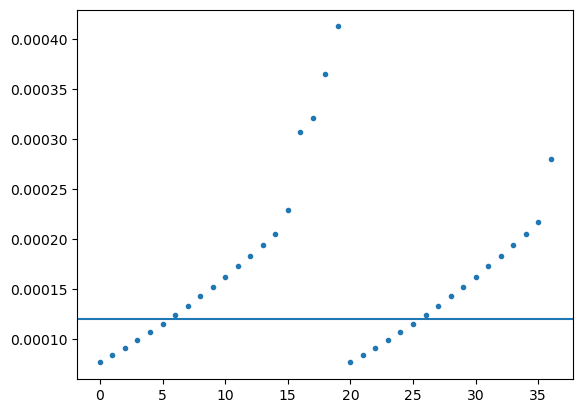

In [503]:
plt.plot(df_length_count["sigma_bs"], ".")
plt.gca().axhline(df_sigma_bs_mean.iloc[0]["sigma_bs_mean"])

In [506]:
df_length_count["weight"] = df_length_count.apply(
    lambda row: (
        10 ** (row["p1"] * np.log10(row["rounded_length"]) + row["p2"])
        if row["has_weight"] else
        0.0
    ),
    axis=1
)

,sex,rounded_length,frequency,operation_number,td_timestamp,td_latitude,td_longitude,stratum,sigma_bs
0,Female,22.0,1,11,20240712000333,37.160085,-122.833601,2,0.000077
1,Female,23.0,1,11,20240712000333,37.160085,-122.833601,2,0.000084
2,Female,24.0,17,11,20240712000333,37.160085,-122.833601,2,0.000091
3,Female,25.0,50,11,20240712000333,37.160085,-122.833601,2,0.000099
4,Female,26.0,58,11,20240712000333,37.160085,-122.833601,2,0.000107
5,Female,27.0,38,11,20240712000333,37.160085,-122.833601,2,0.000116
6,Female,28.0,27,11,20240712000333,37.160085,-122.833601,2,0.000124
7,Female,29.0,10,11,20240712000333,37.160085,-122.833601,2,0.000133
8,Female,30.0,6,11,20240712000333,37.160085,-122.833601,2,0.000143
9,Female,31.0,4,11,20240712000333,37.160085,-122.833601,2,0.000152


In [507]:
df_length_weight_regression

,index,sex,stratum,p1,p2
0,0,female,2,2.989974,-5.178500
1,1,male,2,2.820425,-4.927556
2,0,all,2,2.910460,-5.060112


In [508]:
# First merge the regression coefficients for "all" fish
df_merged = pd.merge(
    df_length_count,
    df_length_weight_regression[df_length_weight_regression["sex"] == "all"][["stratum", "p1", "p2"]],
    on="stratum",
    how="left"
)
df_merged

,sex,rounded_length,frequency,operation_number,td_timestamp,td_latitude,td_longitude,stratum,sigma_bs,p1,p2
0,Female,22.0,1,11,20240712000333,37.160085,-122.833601,2,0.000077,2.91046,-5.060112
1,Female,23.0,1,11,20240712000333,37.160085,-122.833601,2,0.000084,2.91046,-5.060112
2,Female,24.0,17,11,20240712000333,37.160085,-122.833601,2,0.000091,2.91046,-5.060112
3,Female,25.0,50,11,20240712000333,37.160085,-122.833601,2,0.000099,2.91046,-5.060112
4,Female,26.0,58,11,20240712000333,37.160085,-122.833601,2,0.000107,2.91046,-5.060112
5,Female,27.0,38,11,20240712000333,37.160085,-122.833601,2,0.000116,2.91046,-5.060112
6,Female,28.0,27,11,20240712000333,37.160085,-122.833601,2,0.000124,2.91046,-5.060112
7,Female,29.0,10,11,20240712000333,37.160085,-122.833601,2,0.000133,2.91046,-5.060112
8,Female,30.0,6,11,20240712000333,37.160085,-122.833601,2,0.000143,2.91046,-5.060112
9,Female,31.0,4,11,20240712000333,37.160085,-122.833601,2,0.000152,2.91046,-5.060112


In [512]:
# Then compute weight using the length-weight relationship: W = 10^(p1 * log10(L) + p2)
df_merged["weight"] = 10 ** (
    df_merged["p1"] * np.log10(df_merged["rounded_length"]) + df_merged["p2"]
)

In [518]:
df_merged

,sex,rounded_length,frequency,operation_number,td_timestamp,td_latitude,td_longitude,stratum,sigma_bs,p1,p2,weight
0,Female,22.0,1,11,20240712000333,37.160085,-122.833601,2,0.000077,2.91046,-5.060112,0.070300
1,Female,23.0,1,11,20240712000333,37.160085,-122.833601,2,0.000084,2.91046,-5.060112,0.080010
2,Female,24.0,17,11,20240712000333,37.160085,-122.833601,2,0.000091,2.91046,-5.060112,0.090560
3,Female,25.0,50,11,20240712000333,37.160085,-122.833601,2,0.000099,2.91046,-5.060112,0.101985
4,Female,26.0,58,11,20240712000333,37.160085,-122.833601,2,0.000107,2.91046,-5.060112,0.114317
5,Female,27.0,38,11,20240712000333,37.160085,-122.833601,2,0.000116,2.91046,-5.060112,0.127590
6,Female,28.0,27,11,20240712000333,37.160085,-122.833601,2,0.000124,2.91046,-5.060112,0.141835
7,Female,29.0,10,11,20240712000333,37.160085,-122.833601,2,0.000133,2.91046,-5.060112,0.157087
8,Female,30.0,6,11,20240712000333,37.160085,-122.833601,2,0.000143,2.91046,-5.060112,0.173377
9,Female,31.0,4,11,20240712000333,37.160085,-122.833601,2,0.000152,2.91046,-5.060112,0.190738


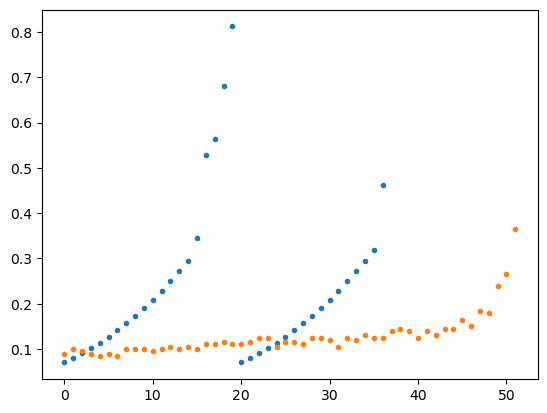

In [516]:
plt.plot(df_merged["weight"], ".")
plt.plot(df_specimen["organism_weight"], ".")

In [521]:
df_weight_mean = df_merged.groupby("stratum").apply(
    lambda df: pd.Series(
        (df["weight"] * df["frequency"]).sum() / df["frequency"].sum(),
        index=["weight_mean"],
    ),
    include_groups=False
).reset_index()
df_weight_mean

,stratum,weight_mean
0,2,0.138422


In [523]:
df_sigma_bs_mean.merge(df_weight_mean, on="stratum", how="outer")

,stratum,sigma_bs_mean,weight_mean
0,2,0.00012,0.138422


In [524]:
def get_sigma_bs_mean_stratum(
    df_length_count: pd.DataFrame,
) -> pd.DataFrame:
    # Compute sigma_bs for each row
    df_length_count["sigma_bs"] = 10 ** ((
        TS_L_PARAMS["slope"] * np.log10(df_length_count["rounded_length"])
        + TS_L_PARAMS["intercept"]
    ) / 10)

    # Get mean sigma_bs for each stratum
    return df_length_count.groupby("stratum").apply(
        lambda df: pd.Series(
            (df["sigma_bs"] * df["frequency"]).sum() / df["frequency"].sum(),
            index=["sigma_bs_mean"],
        ),
        include_groups=False
    ).reset_index()


def get_weight_mean_stratum(
    df_length_count: pd.DataFrame,
    df_length_weight_regression: pd.DataFrame,
) -> pd.DataFrame:
    # Merge length-weight regression coefficients
    df_merged = pd.merge(
        df_length_count,
        df_length_weight_regression[df_length_weight_regression["sex"] == "all"][["stratum", "p1", "p2"]],
        on="stratum",
        how="left"
    )

    # Then compute weight using the length-weight relationship: W = 10^(p1 * log10(L) + p2)
    df_merged["weight"] = 10 ** (
        df_merged["p1"] * np.log10(df_merged["rounded_length"]) + df_merged["p2"]
    )

    # Get mean weight for each stratum
    return df_merged.groupby("stratum").apply(
        lambda df: pd.Series(
            (df["weight"] * df["frequency"]).sum() / df["frequency"].sum(),
            index=["weight_mean"],
        ),
        include_groups=False
    ).reset_index()

In [526]:
# Compute mean sigma_bs and mean weight for each stratum
# columns: stratum, sigma_bs_mean, weight_mean
df_stratum = get_sigma_bs_mean_stratum(df_length_count)
df_weight_mean = get_weight_mean_stratum(df_length_count, df_length_weight_regression)
df_stratum = df_stratum.merge(df_weight_mean, on="stratum", how="outer")


In [527]:
df_stratum

,stratum,sigma_bs_mean,weight_mean
0,2,0.00012,0.138422
